<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Pr%C3%A1ctica_Validaci%C3%B3n%2C_Evaluaci%C3%B3n_y_Selecci%C3%B3n_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📦 Dataset sugerido
Usa el conjunto de datos Glioma Grading Clinical and Mutation Features. Este conjunto de datos lo puedes encontrar en https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

📝 Actividades

El cuaderno deberá contener las siguientes secciones:

**1. Carga de Bibliotecas, Conjunto de Datos y Análisis Exploratorio de los Datos**

Declarar las bibliotecas necesarias para este proyecto
Cargar el conjunto de datos Glioma Grading Clinical and Mutation Features. Se puede descargar de https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

**2. 📊 Análisis exploratorio de datos (EDA)**

Realiza un análisis inicial de los datos antes de modelar:

Describir forma y estructura (shape, describe(), info()).

Mostrar la distribución de clases (y.value_counts()).

Visualizar:

Histograma de al menos 3 variables numéricas.

Boxplots o violin plots por clase si es computacionalmente viable.

Mapa de calor de correlaciones entre variables.

🧠 Reflexiona:

¿Existen clases desbalanceadas?

¿Qué atributos parecen más informativos?

**3. Gráfica de Errores en Entrenamiento y Prueba**

En este ejercicio vas a entrenar un árbol de decisión con diferentes profundidas. Asimismo, en gráfica mostrarás las exactitudes en entrenamiento y test, usando un stratified k-fold cross-validation con K= 10
Los valores de las profundides a evaluar son 2, 5, 10, 15, 20, 25, 30 y None
Deberás usar StratifiedKFold con 10 particiones, y un valor aleaotorio de 3
Entrenarás y evaluarás un árbol de decisión con estos distintos valores de profundidades
Usa cross_val_score para entrenar los modelos, usando como métrica de evaluación en scoring ="f1_macro",y el StratifiedKFold, con un valor aleatorio = 7
Muestra una fráfica para los distintos resultados  cuando se usa F1 Macro

**4. Optimización de hiperparámetros con RandomizedSearchCV**

Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
Criterion = gini ,entropy
max_depth: de 5 a 50 con incrementos de 1
min_samples_split: de 2 a 20 con incrementos de 1
Usa el árbol de decisión
StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
n_iter = 5 (combinaciones aleatorias a buscar)
n_jobs = -1 para acelerar cómputo
Métrica de evaluación: f1 Macro
Imprime los mejores hiperparámetros encontrados
Imprime el best_score

**5. Optimización de hiperparámetros con GridSearchCV**

Define el espacio de búsqueda  para los siguientes hiperpárametros:
Criterion = gini ,entropy
max_depth: de 5 a 50 con incrementos de 1
min_samples_split: de 2 a 20 con incrementos de 1
Usa el árbol de decisión
StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
Métrica de evaluación: f1 Macro
n_jobs = -1 para acelerar cómputo
Imprime los mejores hiperparámetros encontrados
Imprime el best_score

**6. Optimización de hiperparámetros con RandomizedSearchCV: Accuracy**

Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
Criterion = gini ,entropy
max_depth: de 5 a 50 con incrementos de 1
min_samples_split: de 2 a 20 con incrementos de 1
Usa el árbol de decisión
StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
n_iter = 5 (combinaciones aleatorias a buscar)
n_jobs = -1 para acelerar cómputo
Métrica de evaluación: accuracy
Imprime los mejores hiperparámetros encontrados
Imprime el best_score

**7. Optimización de hiperparámetros con GridSearchCV: accuracy**

Define el espacio de búsqueda  para los siguientes hiperpárametros:
Criterion = gini ,entropy
max_depth: de 5 a 50 con incrementos de 1
min_samples_split: de 2 a 20 con incrementos de 1
Usa el árbol de decisión
StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
Métrica de evaluación: f1 Macro
n_jobs = -1 para acelerar cómputo
Imprime los mejores hiperparámetros encontrados
Imprime el best_score

**8.Actividad de reflexión y análisis**

¿Cuál método encontró mejores hiperparámetros?

¿Cuál fue más costoso computacionalmente?

¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? ¿Por qué?

¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? ¿Por qué?

¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?

Aplicar de forma integral el proceso de entrenamiento, ajuste y evaluación de un clasificador tipo Árbol de Decisión sobre un conjunto de datos grande, aplicando técnicas robustas de validación cruzada y optimización de hiperparámetros.

# **1. Carga de Bibliotecas, Conjunto de Datos y Análisis Exploratorio de los Datos**

In [106]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
# =============================================================================
# CARGA DE BIBLIOTECAS Y DATOS
# =============================================================================

# 1. IMPORTAR LAS BIBLIOTECAS NECESARIAS
# ---------------------------------------
# Pandas: para manipular datos en formato de tabla (DataFrames)
import pandas as pd

# NumPy: para operaciones matemáticas y numéricas
import numpy as np

# Matplotlib: para crear gráficas y visualizaciones
import matplotlib.pyplot as plt

# Seaborn: para crear gráficas estadísticas más atractivas
import seaborn as sns

# sklearn (Scikit-learn): biblioteca principal para Machine Learning
# Importamos módulos específicos que usaremos en este proyecto

# Para dividir datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Para crear árboles de decisión
from sklearn.tree import DecisionTreeClassifier

# Para evaluar el rendimiento del modelo
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Para búsqueda de hiperparámetros
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Configuración para mejorar la visualización de las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Para que las gráficas se vean más grandes y claras
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Bibliotecas importadas correctamente")

✓ Bibliotecas importadas correctamente


In [108]:
# =============================================================================
# 2. CARGAR EL CONJUNTO DE DATOS
# =============================================================================

# Ruta del archivo CSV en Google Drive
# IMPORTANTE: Asegúrate de que tu Google Drive esté montado en Colab
ruta_archivo = '/content/drive/MyDrive/Unidad03/TCGA_GBM_LGG_Mutations_all.csv'

# Cargar el dataset usando pandas
# pd.read_csv() lee archivos CSV y los convierte en un DataFrame (tabla)
df = pd.read_csv(ruta_archivo)

print("✓ Datos cargados exitosamente")
print(f"✓ Dimensiones del dataset: {df.shape[0]} filas (pacientes) x {df.shape[1]} columnas (características)")


✓ Datos cargados exitosamente
✓ Dimensiones del dataset: 862 filas (pacientes) x 27 columnas (características)


In [109]:
# =============================================================================
# 3. VISUALIZACIÓN INICIAL DE LOS DATOS
# =============================================================================

# Mostrar las primeras 5 filas del dataset
# Esto nos ayuda a entender qué tipo de datos tenemos
print("\n" + "="*80)
print("PRIMERAS 5 FILAS DEL DATASET:")
print("="*80)
print(df.head())


PRIMERAS 5 FILAS DEL DATASET:
  Grade   Project       Case_ID  Gender   Age_at_diagnosis  \
0   LGG  TCGA-LGG  TCGA-DU-8164    Male  51 years 108 days   
1   LGG  TCGA-LGG  TCGA-QH-A6CY    Male  38 years 261 days   
2   LGG  TCGA-LGG  TCGA-HW-A5KM    Male   35 years 62 days   
3   LGG  TCGA-LGG  TCGA-E1-A7YE  Female  32 years 283 days   
4   LGG  TCGA-LGG  TCGA-S9-A6WG    Male  31 years 187 days   

         Primary_Diagnosis   Race     IDH1         TP53         ATRX  ...  \
0   Oligodendroglioma, NOS  white  MUTATED  NOT_MUTATED  NOT_MUTATED  ...   
1             Mixed glioma  white  MUTATED  NOT_MUTATED  NOT_MUTATED  ...   
2         Astrocytoma, NOS  white  MUTATED      MUTATED      MUTATED  ...   
3  Astrocytoma, anaplastic  white  MUTATED      MUTATED      MUTATED  ...   
4  Astrocytoma, anaplastic  white  MUTATED      MUTATED      MUTATED  ...   

         FUBP1          RB1       NOTCH1         BCOR        CSMD3  \
0      MUTATED  NOT_MUTATED  NOT_MUTATED  NOT_MUTATED  NOT_MUTA

In [110]:
# Mostrar información general del dataset
# Incluye: tipos de datos, cantidad de valores no nulos, uso de memoria
print("\n" + "="*80)
print("INFORMACIÓN GENERAL DEL DATASET:")
print("="*80)
print(df.info())


INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Grade              862 non-null    object
 1   Project            862 non-null    object
 2   Case_ID            862 non-null    object
 3   Gender             862 non-null    object
 4   Age_at_diagnosis   862 non-null    object
 5   Primary_Diagnosis  862 non-null    object
 6   Race               862 non-null    object
 7   IDH1               862 non-null    object
 8   TP53               862 non-null    object
 9   ATRX               862 non-null    object
 10  PTEN               862 non-null    object
 11  EGFR               862 non-null    object
 12  CIC                862 non-null    object
 13  MUC16              862 non-null    object
 14  PIK3CA             862 non-null    object
 15  NF1                862 non-null    object
 16  PIK3R1    

In [111]:
# Verificar si existen valores faltantes (missing values) en el dataset
print("\n" + "="*80)
print("VALORES FALTANTES POR COLUMNA:")
print("="*80)
valores_faltantes = df.isnull().sum()
print(valores_faltantes)
print(f"\n✓ Total de valores faltantes en todo el dataset: {valores_faltantes.sum()}")


VALORES FALTANTES POR COLUMNA:
Grade                0
Project              0
Case_ID              0
Gender               0
Age_at_diagnosis     0
Primary_Diagnosis    0
Race                 0
IDH1                 0
TP53                 0
ATRX                 0
PTEN                 0
EGFR                 0
CIC                  0
MUC16                0
PIK3CA               0
NF1                  0
PIK3R1               0
FUBP1                0
RB1                  0
NOTCH1               0
BCOR                 0
CSMD3                0
SMARCA4              0
GRIN2A               0
IDH2                 0
FAT4                 0
PDGFRA               0
dtype: int64

✓ Total de valores faltantes en todo el dataset: 0


In [112]:
# Estadísticas descriptivas para variables numéricas
# Incluye: media, desviación estándar, mínimo, máximo, cuartiles
print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS (VARIABLES NUMÉRICAS):")
print("="*80)
print(df.describe())


ESTADÍSTICAS DESCRIPTIVAS (VARIABLES NUMÉRICAS):
       Grade   Project       Case_ID Gender Age_at_diagnosis  \
count    862       862           862    862              862   
unique     2         2           862      3              838   
top      LGG  TCGA-LGG  TCGA-06-2557   Male               --   
freq     499       499             1    499                5   

       Primary_Diagnosis   Race         IDH1         TP53         ATRX  ...  \
count                862    862          862          862          862  ...   
unique                 7      6            2            2            2  ...   
top         Glioblastoma  white  NOT_MUTATED  NOT_MUTATED  NOT_MUTATED  ...   
freq                 360    766          448          508          642  ...   

              FUBP1          RB1       NOTCH1         BCOR        CSMD3  \
count           862          862          862          862          862   
unique            2            2            2            2            2   
top     

In [113]:
# =============================================================================
# 4. PREPARAR DATOS PARA EL ANÁLISIS (CORREGIDO)
# =============================================================================

# Separar las características (X) de la variable objetivo (y)
#
# Eliminamos:
# - 'Grade': variable objetivo (target)
# - 'Project': identificador del proyecto (no es característica)
# - 'Case_ID': identificador del caso (no es característica)
#
# La columna 'Grade' indica el tipo de glioma:
# - 0 = LGG (Lower-Grade Glioma - glioma de menor grado)
# - 1 = GBM (Glioblastoma Multiforme - glioma de alto grado)

# Variable objetivo
y = df['Grade']

# Características: todas las columnas EXCEPTO Grade, Project y Case_ID
X = df.drop(['Grade', 'Project', 'Case_ID'], axis=1)

print("Datos separados en características (X) y variable objetivo (y)")
print(f"Forma de X (características): {X.shape}")
print(f"Forma de y (objetivo): {y.shape}")
print(f"Columnas en X: {list(X.columns)}")

Datos separados en características (X) y variable objetivo (y)
Forma de X (características): (862, 24)
Forma de y (objetivo): (862,)
Columnas en X: ['Gender', 'Age_at_diagnosis', 'Primary_Diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']


# **2. 📊 Análisis exploratorio de datos (EDA)**

**Realiza un análisis inicial de los datos antes de modelar:**

In [114]:
# =============================================================================
# CONVERTIR Age_at_diagnosis A NUMÉRICA
# =============================================================================

# Crear una copia del DataFrame original
df_procesado = df.copy()

# Función para extraer años de "XX years YYY days"
def convertir_edad(edad_str):
    if pd.isna(edad_str) or edad_str == '--':
        return np.nan
    try:
        partes = edad_str.split()
        anos = 0
        dias = 0
        if 'year' in edad_str or 'years' in edad_str:
            anos = int(partes[0])
        if 'day' in edad_str or 'days' in edad_str:
            idx_dias = partes.index('days') if 'days' in partes else partes.index('day')
            dias = int(partes[idx_dias - 1])
        edad_total = anos + (dias / 365.25)
        return edad_total
    except:
        return np.nan

df_procesado['Age_numeric'] = df['Age_at_diagnosis'].apply(convertir_edad)
df_procesado['Age_numeric'].fillna(df_procesado['Age_numeric'].mean(), inplace=True)

print("✓ Age_at_diagnosis convertida a numérica")

✓ Age_at_diagnosis convertida a numérica


/tmp/ipython-input-2866436809.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_procesado['Age_numeric'].fillna(df_procesado['Age_numeric'].mean(), inplace=True)


In [115]:
# =============================================================================
# CONVERTIR Gender A NUMÉRICA
# =============================================================================

# Male = 0, Female = 1
df_procesado['Gender_numeric'] = (df['Gender'] == 'Female').astype(int)

print("✓ Gender convertida a numérica (Male=0, Female=1)")

✓ Gender convertida a numérica (Male=0, Female=1)


In [116]:
# =============================================================================
# CONVERTIR Race A ONE-HOT ENCODING
# =============================================================================

# Crear columnas binarias para cada categoría de Race
race_dummies = pd.get_dummies(df['Race'], prefix='Race', dtype=int)
df_procesado = pd.concat([df_procesado, race_dummies], axis=1)

print("✓ Race convertida a One-Hot Encoding")
print(f"  Columnas de Race creadas: {race_dummies.columns.tolist()}")

✓ Race convertida a One-Hot Encoding
  Columnas de Race creadas: ['Race_--', 'Race_american indian or alaska native', 'Race_asian', 'Race_black or african american', 'Race_not reported', 'Race_white']


In [117]:
# =============================================================================
# CODIFICAR VARIABLES DE MUTACIÓN
# =============================================================================

# Obtener todas las columnas originales (excepto identificadores, Gender, Age, Race, Primary_Diagnosis)
columnas_originales = df.columns[~df.columns.isin(['Grade', 'Project', 'Case_ID', 'Gender',
                                                      'Age_at_diagnosis', 'Race', 'Primary_Diagnosis'])]

# Codificar cada variable de mutación
for col in columnas_originales:
    if col in df_procesado.columns:
        valores_unicos = df_procesado[col].unique()
        if any('MUTATED' in str(val) for val in valores_unicos if pd.notna(val)):
            df_procesado[col] = (df_procesado[col] == 'MUTATED').astype(int)

print("✓ Variables de mutación codificadas")
print(f"  Total de variables de mutación: {len(columnas_originales)}")

✓ Variables de mutación codificadas
  Total de variables de mutación: 20


In [118]:
# =============================================================================
# CREAR X e y FINALES
# =============================================================================

# Eliminar columnas no numéricas y identificadores
columnas_eliminar = ['Grade', 'Project', 'Case_ID', 'Gender', 'Age_at_diagnosis', 'Race', 'Primary_Diagnosis']

X = df_procesado.drop(columnas_eliminar, axis=1)
y = df_procesado['Grade']

print("✓ X e y creadas")
print(f"  Forma de X: {X.shape}")
print(f"  Forma de y: {y.shape}")

✓ X e y creadas
  Forma de X: (862, 28)
  Forma de y: (862,)


In [119]:
# =============================================================================
# VERIFICACIÓN FINAL DEL PREPROCESAMIENTO
# =============================================================================

print("\n" + "="*80)
print("VERIFICACIÓN FINAL DEL PREPROCESAMIENTO")
print("="*80)

# Verificar que NO hay columnas de tipo 'object'
columnas_object = X.columns[X.dtypes == 'object'].tolist()

if len(columnas_object) == 0:
    print("✓ Todas las columnas en X son numéricas: True")
else:
    print(f"Columnas de tipo 'object' encontradas: {columnas_object}")

print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Tipos de datos únicos en X: {X.dtypes.unique()}")


VERIFICACIÓN FINAL DEL PREPROCESAMIENTO
✓ Todas las columnas en X son numéricas: True

Forma de X: (862, 28)
Forma de y: (862,)
Tipos de datos únicos en X: [dtype('int64') dtype('float64')]


**Describir forma y estructura (shape, describe(), info()).**

In [120]:
print("="*80)
print("FORMA DEL DATASET")
print("="*80)
print(f"Dimensiones: {df_procesado.shape}")
print(f"Número de filas (pacientes): {df_procesado.shape[0]}")
print(f"Número de columnas (variables): {df_procesado.shape[1]}")

FORMA DEL DATASET
Dimensiones: (862, 35)
Número de filas (pacientes): 862
Número de columnas (variables): 35


In [121]:
print("\n" + "="*80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*80)
df_procesado.info()


INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Grade                                  862 non-null    object 
 1   Project                                862 non-null    object 
 2   Case_ID                                862 non-null    object 
 3   Gender                                 862 non-null    object 
 4   Age_at_diagnosis                       862 non-null    object 
 5   Primary_Diagnosis                      862 non-null    object 
 6   Race                                   862 non-null    object 
 7   IDH1                                   862 non-null    int64  
 8   TP53                                   862 non-null    int64  
 9   ATRX                                   862 non-null    int64  
 10  PTEN                                   86

In [122]:
print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS DEL DATASET PROCESADO")
print("="*80)
print(df_procesado.describe())


ESTADÍSTICAS DESCRIPTIVAS DEL DATASET PROCESADO
             IDH1        TP53        ATRX        PTEN        EGFR         CIC  \
count  862.000000  862.000000  862.000000  862.000000  862.000000  862.000000   
mean     0.480278    0.410673    0.255220    0.167053    0.132251    0.132251   
std      0.499901    0.492242    0.436238    0.373240    0.338960    0.338960   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      1.000000    1.000000    1.000000    0.000000    0.000000    0.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

            MUC16      PIK3CA         NF1      PIK3R1  ...        FAT4  \
count  862.000000  862.000000  862.000000  862.000000  ...  862.000000   
mean     0.116009    0.089327    0.080046    0.066125  ...    0.026682   

In [123]:
print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS DE X (CARACTERÍSTICAS)")
print("="*80)
print(X.describe())


ESTADÍSTICAS DESCRIPTIVAS DE X (CARACTERÍSTICAS)
             IDH1        TP53        ATRX        PTEN        EGFR         CIC  \
count  862.000000  862.000000  862.000000  862.000000  862.000000  862.000000   
mean     0.480278    0.410673    0.255220    0.167053    0.132251    0.132251   
std      0.499901    0.492242    0.436238    0.373240    0.338960    0.338960   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      1.000000    1.000000    1.000000    0.000000    0.000000    0.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

            MUC16      PIK3CA         NF1      PIK3R1  ...        FAT4  \
count  862.000000  862.000000  862.000000  862.000000  ...  862.000000   
mean     0.116009    0.089327    0.080046    0.066125  ...    0.026682  

**Mostrar la distribución de clases (y.value_counts()).**

In [124]:
print("\n" + "="*80)
print("DISTRIBUCIÓN DE CLASES (FRECUENCIAS)")
print("="*80)
print(y.value_counts())


DISTRIBUCIÓN DE CLASES (FRECUENCIAS)
Grade
LGG    499
GBM    363
Name: count, dtype: int64


In [125]:
print("\n" + "="*80)
print("DISTRIBUCIÓN DE CLASES (PORCENTAJES)")
print("="*80)
porcentajes = y.value_counts(normalize=True) * 100
print(porcentajes)


DISTRIBUCIÓN DE CLASES (PORCENTAJES)
Grade
LGG    57.888631
GBM    42.111369
Name: proportion, dtype: float64


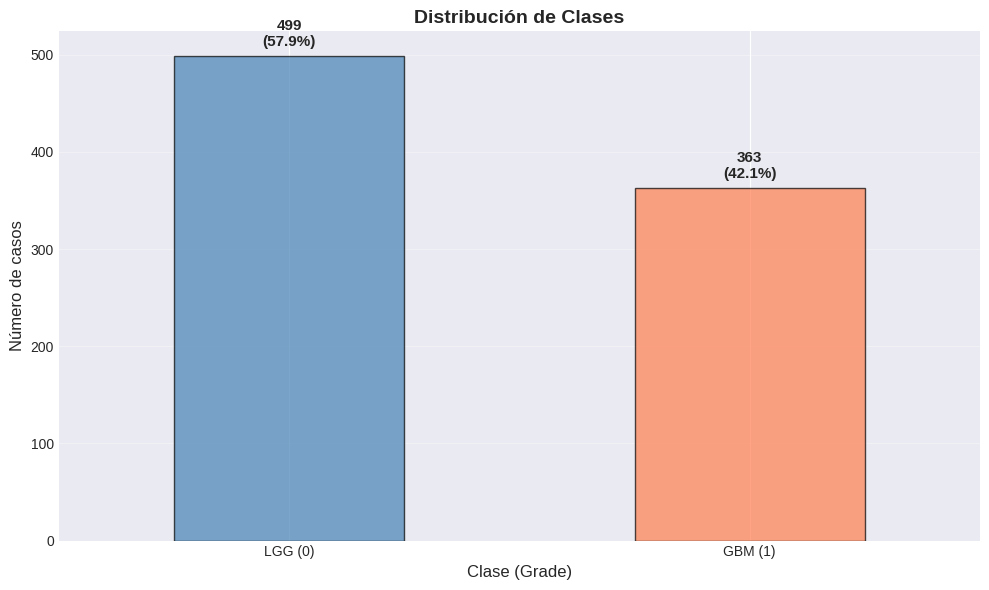

In [126]:
distribucion = y.value_counts()

plt.figure(figsize=(10, 6))
distribucion.plot(kind='bar', color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
plt.title('Distribución de Clases', fontsize=14, fontweight='bold')
plt.xlabel('Clase (Grade)', fontsize=12)
plt.ylabel('Número de casos', fontsize=12)
plt.xticks([0, 1], ['LGG (0)', 'GBM (1)'], rotation=0)

for i, valor in enumerate(distribucion.values):
    plt.text(i, valor + 10, f'{valor}\n({porcentajes.iloc[i]:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Visualizar:**

Variables seleccionadas para histogramas: ['Age_numeric', 'Gender_numeric', 'EGFR', 'CIC', 'MUC16', 'PIK3CA']


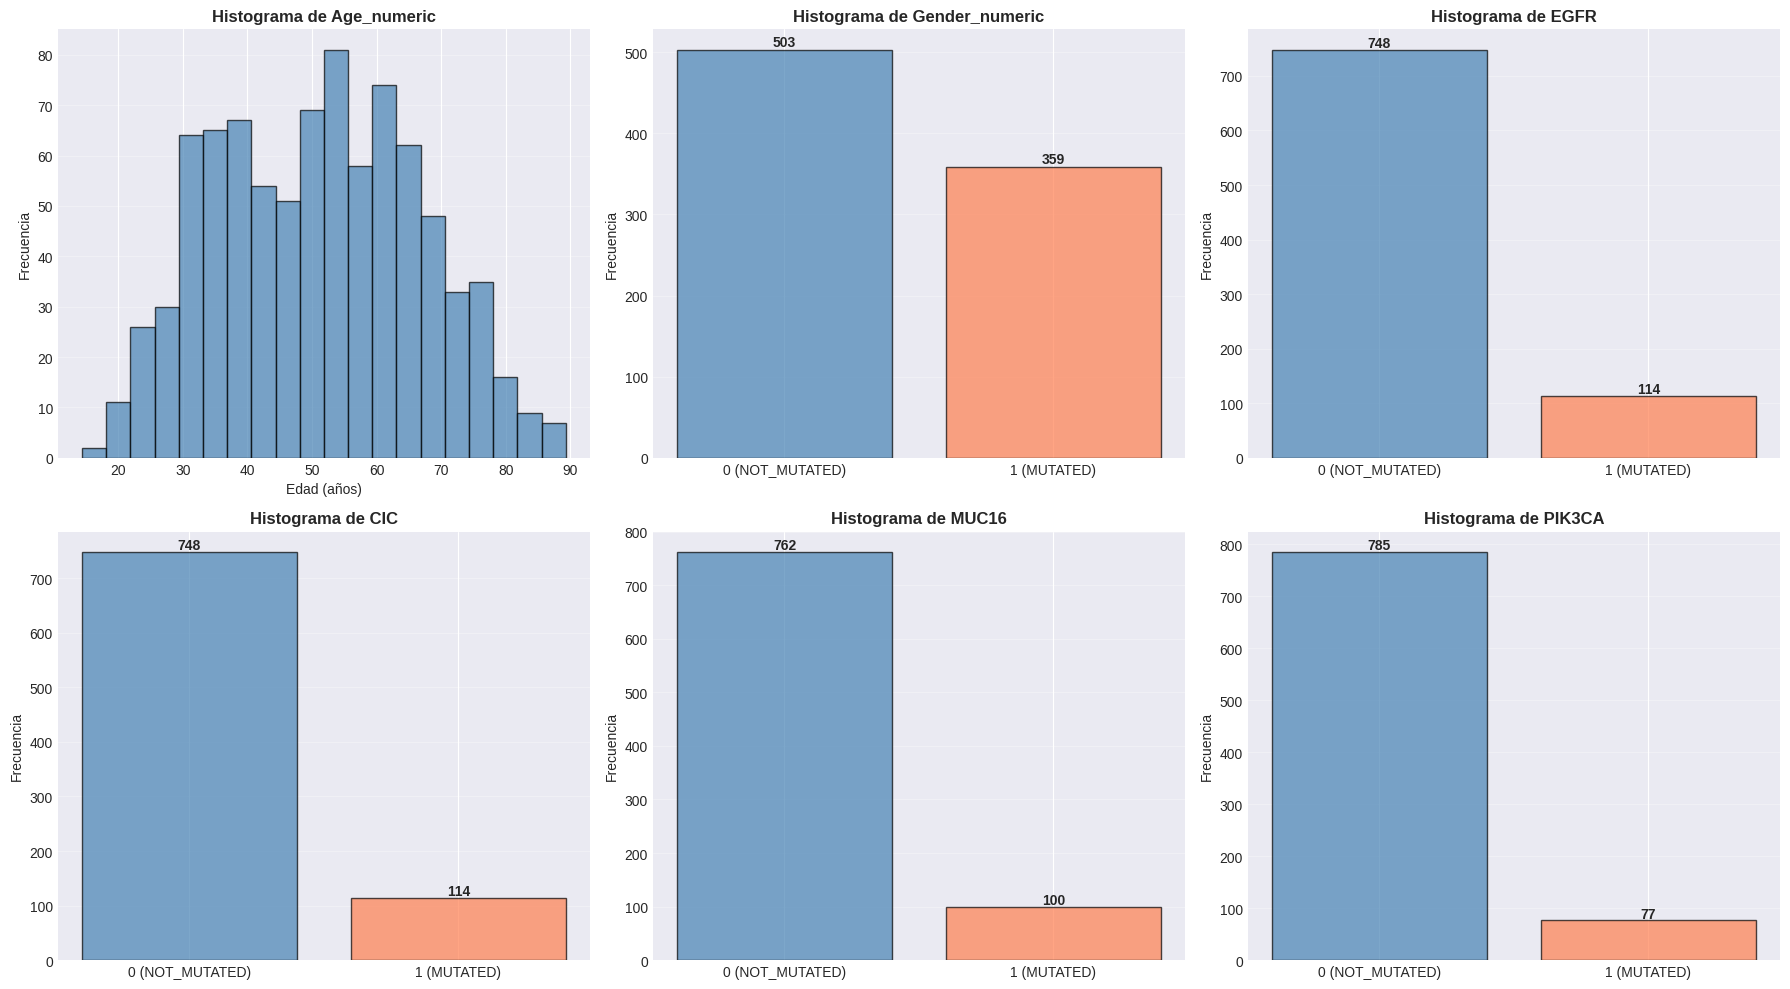

In [127]:
# Seleccionar 6 variables: Age_numeric, Gender_numeric + 4 variables de mutación
variables_a_graficar = ['Age_numeric', 'Gender_numeric'] + X.columns[4:8].tolist()

print(f"Variables seleccionadas para histogramas: {variables_a_graficar}")

# Crear figura con 6 subgráficas (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Crear histograma para cada variable
for i, variable in enumerate(variables_a_graficar):
    if variable == 'Age_numeric':
        # Histograma tradicional para variable continua
        axes[i].hist(X[variable], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
        axes[i].set_title(f'Histograma de {variable}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Edad (años)', fontsize=10)
        axes[i].set_ylabel('Frecuencia', fontsize=10)

    else:
        # Barras para variables binarias
        conteo = X[variable].value_counts().sort_index()
        axes[i].bar(['0 (NOT_MUTATED)', '1 (MUTATED)'],
                    [conteo.get(0, 0), conteo.get(1, 0)],
                    color=['steelblue', 'coral'],
                    alpha=0.7,
                    edgecolor='black')
        axes[i].set_title(f'Histograma de {variable}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Frecuencia', fontsize=10)

        for j, valor in enumerate([conteo.get(0, 0), conteo.get(1, 0)]):
            axes[i].text(j, valor + 5, str(valor), ha='center', fontsize=10, fontweight='bold')

    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [134]:
# =============================================================================
# GUARDAR Age_numeric CON VALORES STRING ('LGG' Y 'GBM')
# =============================================================================

# Los valores en y son strings, así que usamos 'LGG' y 'GBM' directamente
valor_lgg = 'LGG'
valor_gbm = 'GBM'

# Extraer los valores de edad para cada clase
# y == 'LGG': obtiene todas las filas donde y es igual a 'LGG'
# .dropna(): elimina valores faltantes
# .values: convierte a array numpy
age_lgg = df_procesado.loc[y == 'LGG', 'Age_numeric'].dropna().values
age_gbm = df_procesado.loc[y == 'GBM', 'Age_numeric'].dropna().values

# Mostrar información
print("="*80)
print("INFORMACIÓN DE Age_numeric GUARDADA")
print("="*80)
print(f"LGG:")
print(f"  - Casos: {len(age_lgg)}")
if len(age_lgg) > 0:
    print(f"  - Edad mínima: {age_lgg.min():.2f} años")
    print(f"  - Edad máxima: {age_lgg.max():.2f} años")
    print(f"  - Edad promedio: {age_lgg.mean():.2f} años")
else:
    print(f"  - SIN DATOS")

print(f"\nGBM:")
print(f"  - Casos: {len(age_gbm)}")
if len(age_gbm) > 0:
    print(f"  - Edad mínima: {age_gbm.min():.2f} años")
    print(f"  - Edad máxima: {age_gbm.max():.2f} años")
    print(f"  - Edad promedio: {age_gbm.mean():.2f} años")
else:
    print(f"  - SIN DATOS")


INFORMACIÓN DE Age_numeric GUARDADA
LGG:
  - Casos: 499
  - Edad mínima: 14.42 años
  - Edad máxima: 87.00 años
  - Edad promedio: 43.79 años

GBM:
  - Casos: 363
  - Edad mínima: 21.73 años
  - Edad máxima: 89.29 años
  - Edad promedio: 60.72 años


/tmp/ipython-input-1819502357.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([age_lgg, age_gbm],


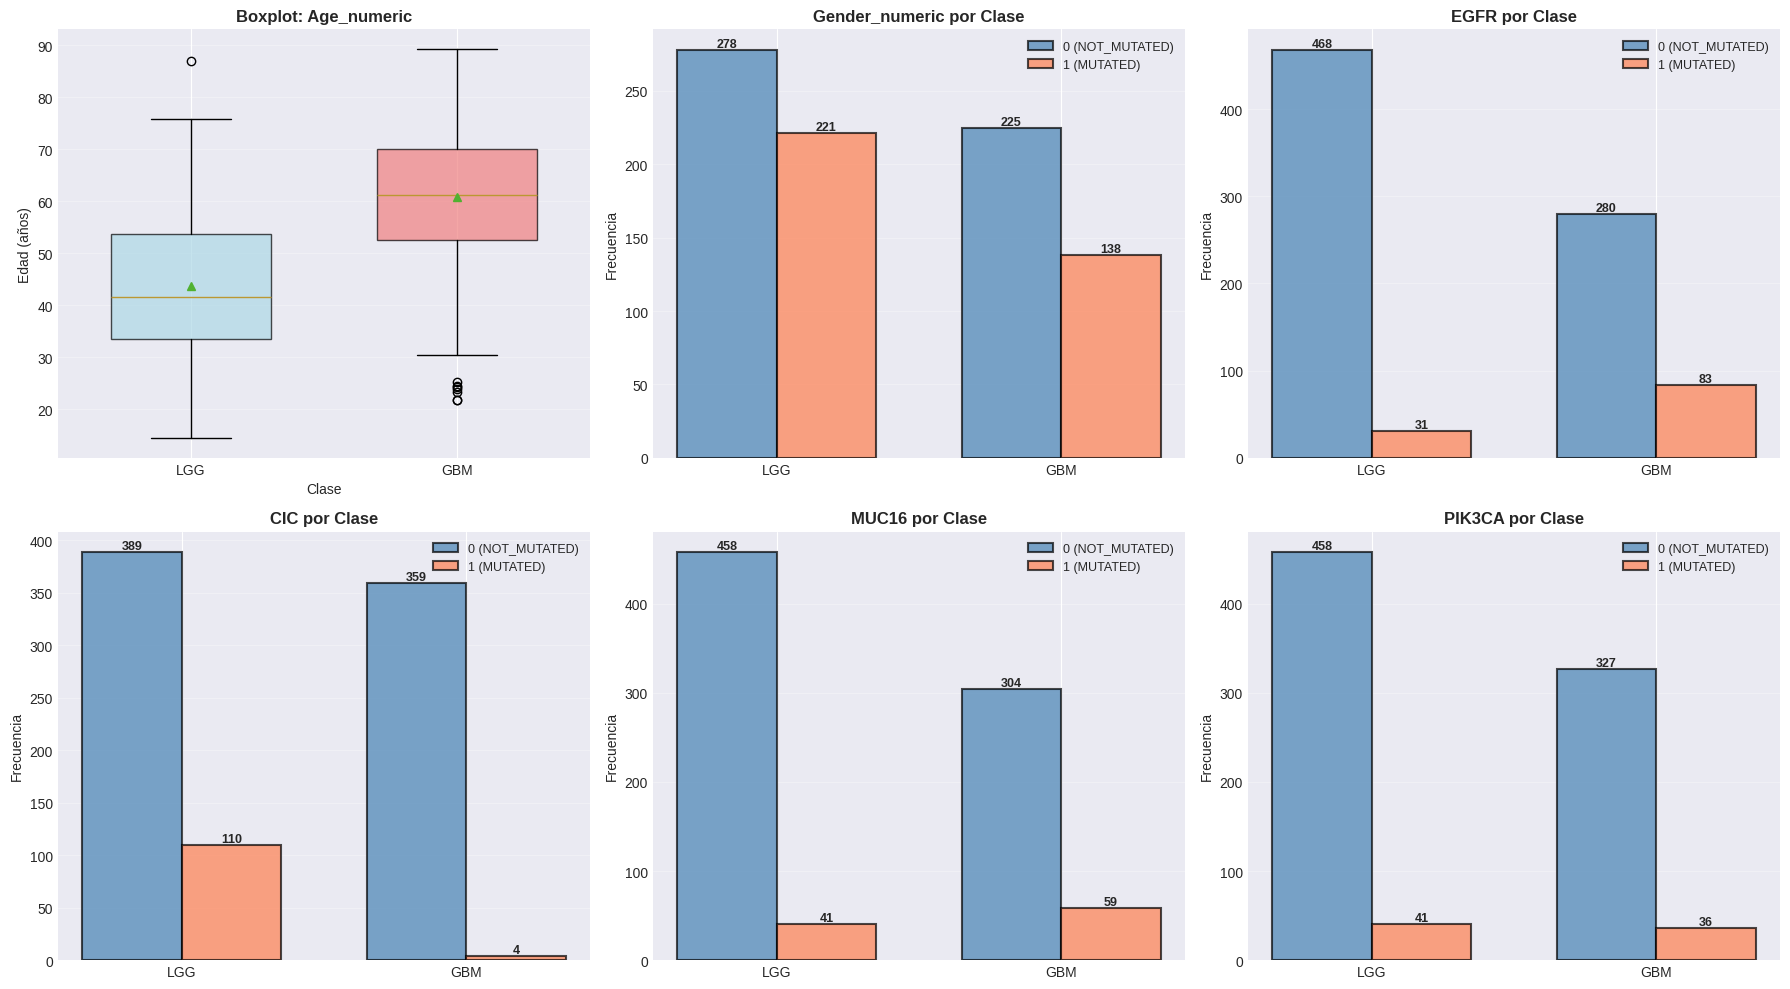

In [135]:
# =============================================================================
# CREAR BOXPLOTS Y GRÁFICAS POR CLASE
# =============================================================================

# Crear figura con 6 subgráficas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Iterar sobre cada variable
for i, variable in enumerate(variables_a_graficar):

    if variable == 'Age_numeric':

        # Verificar que tenemos datos
        if len(age_lgg) > 0 and len(age_gbm) > 0:

            # Crear boxplot con los datos guardados
            bp = axes[i].boxplot([age_lgg, age_gbm],
                                 positions=[1, 2],
                                 labels=['LGG', 'GBM'],
                                 patch_artist=True,
                                 widths=0.6,
                                 showmeans=True)

            # Colorear los boxes
            for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            axes[i].set_title(f'Boxplot: {variable}', fontsize=12, fontweight='bold')
            axes[i].set_ylabel('Edad (años)', fontsize=10)
            axes[i].set_xlabel('Clase', fontsize=10)
            axes[i].grid(axis='y', alpha=0.3)

        else:
            axes[i].text(0.5, 0.5, 'Sin datos disponibles',
                        ha='center', va='center',
                        transform=axes[i].transAxes,
                        fontsize=10, color='red', fontweight='bold')

    else:

        try:
            # Para variables binarias, filtrar por y == 'LGG' o y == 'GBM'
            lgg_data = X.loc[y == 'LGG', variable].astype(int)
            gbm_data = X.loc[y == 'GBM', variable].astype(int)

            lgg_vals = lgg_data.value_counts()
            gbm_vals = gbm_data.value_counts()

            val_0_lgg = int(lgg_vals.get(0, 0))
            val_1_lgg = int(lgg_vals.get(1, 0))
            val_0_gbm = int(gbm_vals.get(0, 0))
            val_1_gbm = int(gbm_vals.get(1, 0))

            x_pos = np.array([1, 2])
            width = 0.35

            b1 = axes[i].bar(x_pos - width/2, [val_0_lgg, val_0_gbm],
                             width, label='0 (NOT_MUTATED)', color='steelblue',
                             alpha=0.7, edgecolor='black', linewidth=1.5)
            b2 = axes[i].bar(x_pos + width/2, [val_1_lgg, val_1_gbm],
                             width, label='1 (MUTATED)', color='coral',
                             alpha=0.7, edgecolor='black', linewidth=1.5)

            for bar in b1:
                height = bar.get_height()
                if height > 0:
                    axes[i].text(bar.get_x() + bar.get_width()/2., height,
                                f'{int(height)}', ha='center', va='bottom',
                                fontsize=9, fontweight='bold')
            for bar in b2:
                height = bar.get_height()
                if height > 0:
                    axes[i].text(bar.get_x() + bar.get_width()/2., height,
                                f'{int(height)}', ha='center', va='bottom',
                                fontsize=9, fontweight='bold')

            axes[i].set_title(f'{variable} por Clase', fontsize=12, fontweight='bold')
            axes[i].set_xticks(x_pos)
            axes[i].set_xticklabels(['LGG', 'GBM'], fontsize=10)
            axes[i].set_ylabel('Frecuencia', fontsize=10)
            axes[i].legend(loc='upper right', fontsize=9)
            axes[i].grid(axis='y', alpha=0.3)

        except Exception as e:
            print(f"Error en {variable}: {str(e)}")
            axes[i].text(0.5, 0.5, f'Error', ha='center', va='center',
                        transform=axes[i].transAxes, fontsize=8, color='red')

plt.tight_layout()
plt.show()

Las variables Gender_numeric, EGFR, CIC, MUC16 y PIK3CA son binarias (solo tienen valores 0 y 1)

**Boxplots y violin plots están diseñados para variables continuas o variables con múltiples valores discretos**

Con solo 2 valores posibles, no hay suficiente variabilidad para visualizar:

Quartiles: el Q1, mediana y Q3 colapsan a puntos únicos (todos están en 0 o 1)

Distribución: un violin plot sería una línea vertical, no una forma significativa

Outliers: con valores 0/1, no pueden existir outliers verdaderos

**Visualización que resulta:**

El boxplot mostraría líneas planas

No proporcionaría información adicional, Sería confuso para el lector, sugiriendo más complejidad de la que realmente existe.

Total de variables en X: 28
Variables: ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA', 'Age_numeric', 'Gender_numeric', 'Race_--', 'Race_american indian or alaska native', 'Race_asian', 'Race_black or african american', 'Race_not reported', 'Race_white']

Matriz de correlaciones calculada: (29, 29)


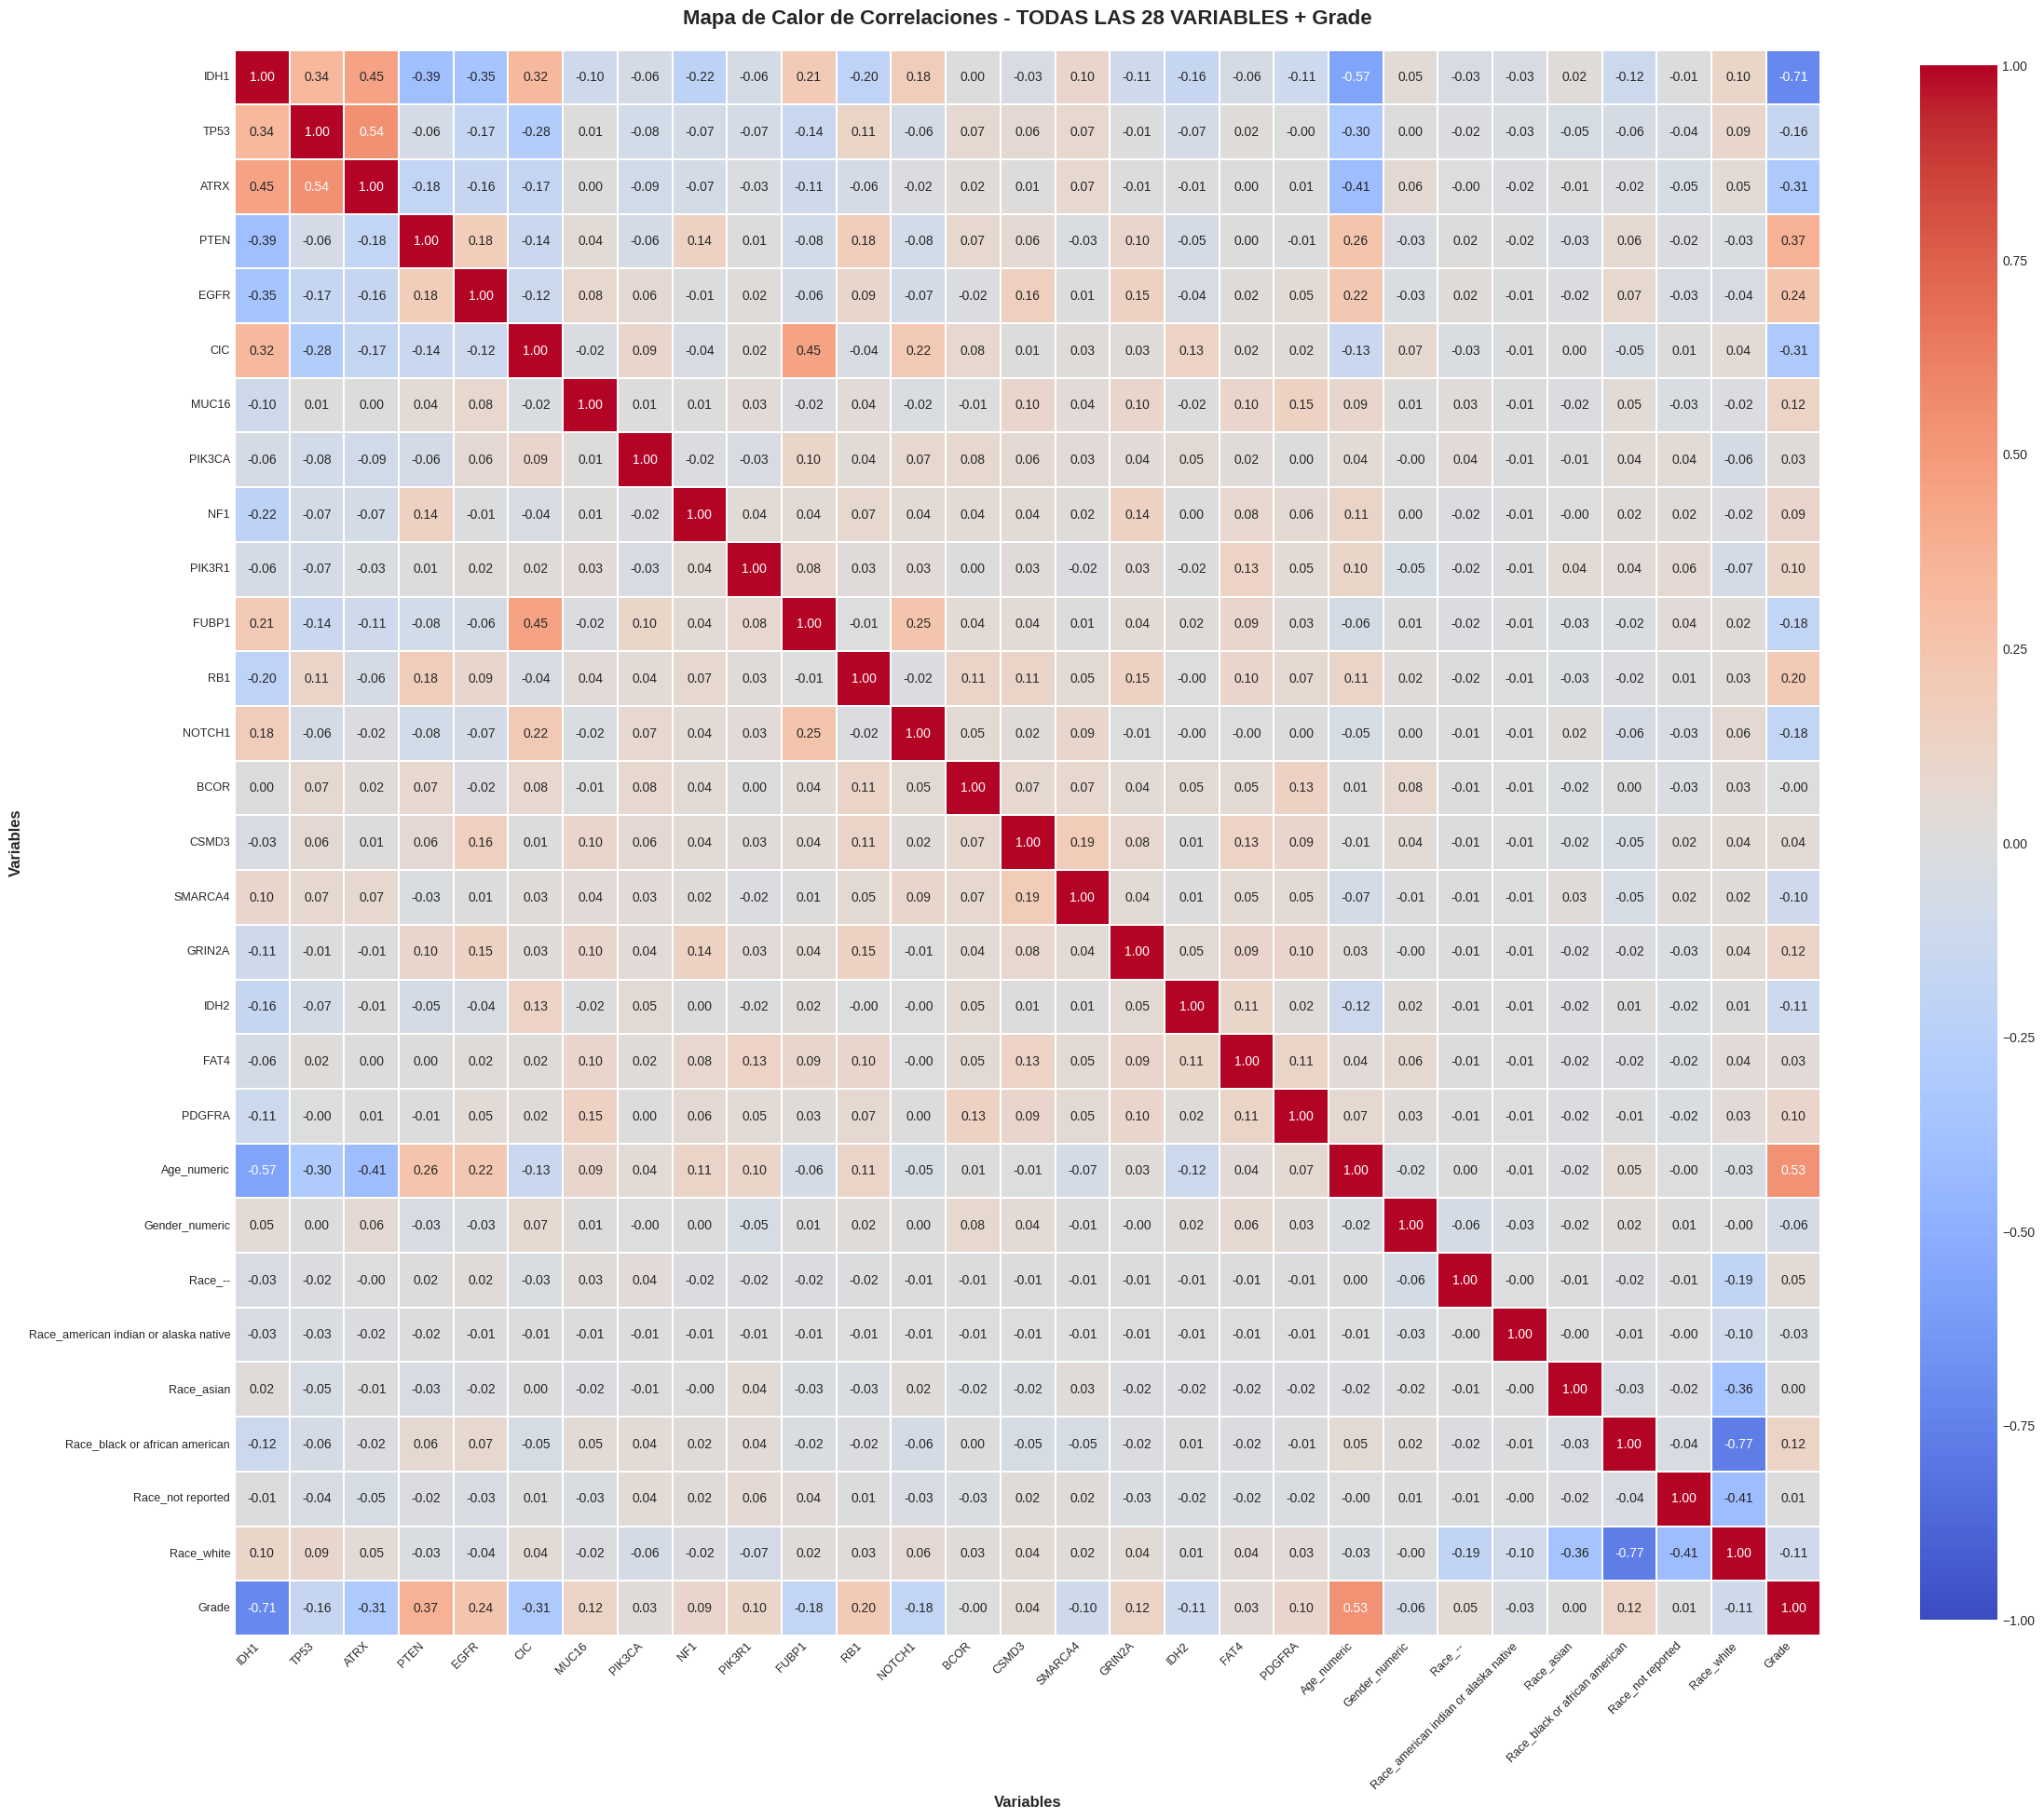


ANÁLISIS DE CORRELACIONES CON GRADE (Variable Target)

Top 15 variables MÁS CORRELACIONADAS con Grade:
Variable                      Correlación       Interpretación
-----------------------------------------------------------------
IDH1                              -0.7117      Fuerte negativa
Age_numeric                        0.5332      Fuerte positiva
PTEN                               0.3676    Moderada positiva
ATRX                              -0.3107    Moderada negativa
CIC                               -0.3052    Moderada negativa
EGFR                               0.2427       Débil positiva
RB1                                0.1958       Débil positiva
FUBP1                             -0.1841       Débil negativa
NOTCH1                            -0.1832       Débil negativa
TP53                              -0.1580       Débil negativa
MUC16                              0.1239       Débil positiva
Race_black or african american          0.1224       Débil positiva
GRIN2A

In [138]:
# =============================================================================
# MAPA DE CALOR DE CORRELACIONES CON TODAS LAS VARIABLES
# =============================================================================

print(f"Total de variables en X: {X.shape[1]}")
print(f"Variables: {X.columns.tolist()}")

# Usar TODAS las columnas de X
df_correlacion_completo = X.copy()

# Convertir Grade a numérica: LGG=0, GBM=1
# Esto permite ver la correlación entre cada variable y la clase objetivo
df_correlacion_completo['Grade'] = (y == 'GBM').astype(int)

# Calcular la matriz de correlaciones de Pearson
# Mide la correlación lineal entre todas las variables
matriz_correlacion_completa = df_correlacion_completo.corr()

print(f"\nMatriz de correlaciones calculada: {matriz_correlacion_completa.shape}")

# Crear la figura para el mapa de calor con TODAS las variables
# Aumentamos el tamaño de la figura para mejor legibilidad
plt.figure(figsize=(24, 22))

# Crear el mapa de calor con todas las variables
sns.heatmap(matriz_correlacion_completa,
            annot=True,              # Mostrar valores en cada celda
            fmt='.2f',               # Formato: 2 decimales
            cmap='coolwarm',         # Colormap: rojo (negativo) - blanco (0) - azul (positivo)
            center=0,                # Centrar la escala en 0
            square=True,             # Celdas cuadradas
            linewidths=0.3,          # Líneas finas entre celdas
            cbar_kws={"shrink": 0.8},  # Barra de colores
            vmin=-1, vmax=1)         # Rango de valores: -1 a +1

# Configurar títulos y etiquetas
plt.title(f'Mapa de Calor de Correlaciones - TODAS LAS {X.shape[1]} VARIABLES + Grade',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Variables', fontsize=12, fontweight='bold')
plt.ylabel('Variables', fontsize=12, fontweight='bold')

# Rotar las etiquetas para mejor legibilidad
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

# Ajustar espacios
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# =========================================================================
# ANÁLISIS DETALLADO DE CORRELACIONES
# =========================================================================

print("\n" + "="*80)
print("ANÁLISIS DE CORRELACIONES CON GRADE (Variable Target)")
print("="*80)

# Extraer la columna de Grade y ordenarla por valor absoluto
correlaciones_grade = matriz_correlacion_completa['Grade'].drop('Grade')
correlaciones_grade_abs = correlaciones_grade.abs().sort_values(ascending=False)

print(f"\nTop 15 variables MÁS CORRELACIONADAS con Grade:")
print(f"{'Variable':<25} {'Correlación':>15} {'Interpretación':>20}")
print("-" * 65)

for variable in correlaciones_grade_abs.head(15).index:
    valor_corr = correlaciones_grade[variable]
    # Interpretación
    if valor_corr > 0.5:
        interp = "Fuerte positiva"
    elif valor_corr > 0.3:
        interp = "Moderada positiva"
    elif valor_corr > 0:
        interp = "Débil positiva"
    elif valor_corr < -0.5:
        interp = "Fuerte negativa"
    elif valor_corr < -0.3:
        interp = "Moderada negativa"
    else:
        interp = "Débil negativa"

    print(f"{variable:<25} {valor_corr:>15.4f} {interp:>20}")

# =========================================================================
# MULTICOLINEALIDAD: Variables altamente correlacionadas entre sí
# =========================================================================

print("\n" + "="*80)
print("ANÁLISIS DE MULTICOLINEALIDAD (Correlaciones > 0.7 entre variables)")
print("="*80)

# Encontrar correlaciones fuertes (sin contar la diagonal)
correlaciones_fuertes = []

# Recorrer la matriz triangular superior (evitar duplicados)
for i in range(len(matriz_correlacion_completa.columns)):
    for j in range(i+1, len(matriz_correlacion_completa.columns)):
        var1 = matriz_correlacion_completa.columns[i]
        var2 = matriz_correlacion_completa.columns[j]
        corr_valor = matriz_correlacion_completa.iloc[i, j]

        # Solo guardar si la correlación es fuerte (> 0.7 o < -0.7)
        if abs(corr_valor) > 0.7:
            correlaciones_fuertes.append((var1, var2, corr_valor))

# Ordenar por valor absoluto de correlación
correlaciones_fuertes.sort(key=lambda x: abs(x[2]), reverse=True)

if correlaciones_fuertes:
    print(f"\nEncontradas {len(correlaciones_fuertes)} pares de variables altamente correlacionadas:")
    print(f"\n{'Variable 1':<20} {'Variable 2':<20} {'Correlación':>15}")
    print("-" * 60)

    for var1, var2, corr in correlaciones_fuertes:
        print(f"{var1:<20} {var2:<20} {corr:>15.4f}")
else:
    print("\nNo hay correlaciones fuertes (> 0.7) entre variables.")

# =========================================================================
# RESUMEN ESTADÍSTICO
# =========================================================================

print("\n" + "="*80)
print("RESUMEN ESTADÍSTICO DE CORRELACIONES")
print("="*80)

# Estadísticas de la correlación con Grade (excluyendo Grade mismo)
corr_grade_values = correlaciones_grade.values

print(f"\nCorrelación con Grade:")
print(f"  - Correlación máxima: {corr_grade_values.max():.4f}")
print(f"  - Correlación mínima: {corr_grade_values.min():.4f}")
print(f"  - Correlación promedio: {corr_grade_values.mean():.4f}")
print(f"  - Desviación estándar: {corr_grade_values.std():.4f}")

# Contar correlaciones por nivel
fuerte_pos = (correlaciones_grade > 0.5).sum()
moderada_pos = ((correlaciones_grade > 0.3) & (correlaciones_grade <= 0.5)).sum()
debil_pos = ((correlaciones_grade > 0) & (correlaciones_grade <= 0.3)).sum()
fuerte_neg = (correlaciones_grade < -0.5).sum()
moderada_neg = ((correlaciones_grade < -0.3) & (correlaciones_grade >= -0.5)).sum()
debil_neg = ((correlaciones_grade < 0) & (correlaciones_grade >= -0.3)).sum()

print(f"\nDistribución de correlaciones con Grade:")
print(f"  - Fuerte positiva (> 0.5): {fuerte_pos}")
print(f"  - Moderada positiva (0.3-0.5): {moderada_pos}")
print(f"  - Débil positiva (0-0.3): {debil_pos}")
print(f"  - Fuerte negativa (< -0.5): {fuerte_neg}")
print(f"  - Moderada negativa (-0.5 a -0.3): {moderada_neg}")
print(f"  - Débil negativa (-0.3 a 0): {debil_neg}")

# **🧠 Reflexiona:**

# **¿Existen clases desbalanceadas?**

ANÁLISIS DE DESBALANCE DE CLASES

1. CONTEOS ABSOLUTOS:
Grade
LGG    499
GBM    363
Name: count, dtype: int64

2. PORCENTAJES:
Grade
LGG    57.89
GBM    42.11
Name: proportion, dtype: float64

3. ANÁLISIS:
  - LGG: 499 casos (57.89%)
  - GBM: 363 casos (42.11%)
  - Ratio LGG/GBM: 1.37
  - Diferencia: 136 casos

4. CONCLUSIÓN:
  ✅ CLASES RELATIVAMENTE BALANCEADAS
     Ambas clases están entre 40-60%


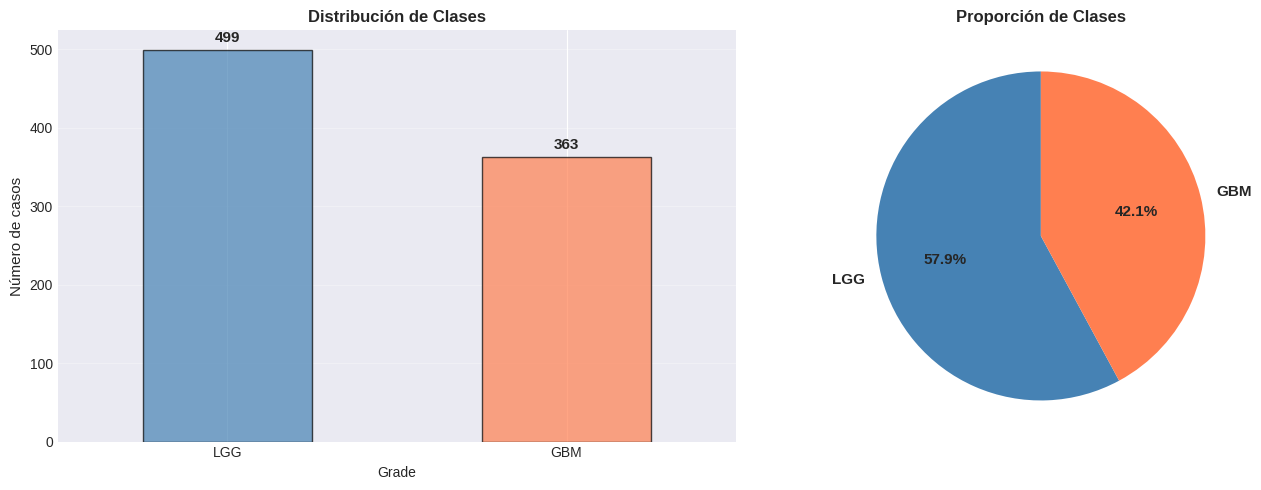

In [141]:
# =============================================================================
# ANÁLISIS DE DESBALANCE DE CLASES (Basado en concepto de StratifiedKFold)
# =============================================================================

print("="*80)
print("ANÁLISIS DE DESBALANCE DE CLASES")
print("="*80)

# Contar casos por clase
conteos_clase = y.value_counts()
print("\n1. CONTEOS ABSOLUTOS:")
print(conteos_clase)

# Calcular porcentajes
porcentajes_clase = (y.value_counts(normalize=True) * 100).round(2)
print("\n2. PORCENTAJES:")
print(porcentajes_clase)

# Calcular ratio
lgg_count = (y == 'LGG').sum()
gbm_count = (y == 'GBM').sum()
ratio = lgg_count / gbm_count

print(f"\n3. ANÁLISIS:")
print(f"  - LGG: {lgg_count} casos ({porcentajes_clase['LGG']}%)")
print(f"  - GBM: {gbm_count} casos ({porcentajes_clase['GBM']}%)")
print(f"  - Ratio LGG/GBM: {ratio:.2f}")
print(f"  - Diferencia: {abs(lgg_count - gbm_count)} casos")

# Necesidad de StratifiedKFold
print(f"\n4. CONCLUSIÓN:")
if min(porcentajes_clase) < 40:
    print(f"  ⚠️  SÍ EXISTEN CLASES DESBALANCEADAS")
    print(f"     La clase minoritaria ({conteos_clase.index[1]}) es {min(porcentajes_clase):.1f}%")
    print(f"     Recomendación del PDF: Usar StratifiedKFold en validación")
else:
    print(f"  ✅ CLASES RELATIVAMENTE BALANCEADAS")
    print(f"     Ambas clases están entre 40-60%")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
conteos_clase.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[0].set_title('Distribución de Clases', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de casos', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(conteos_clase.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11, fontweight='bold')

# Pastel
axes[1].pie(conteos_clase.values, labels=conteos_clase.index, autopct='%1.1f%%',
            colors=['steelblue', 'coral'], startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# **¿Qué atributos parecen más informativos?**


ATRIBUTOS MÁS INFORMATIVOS - Ganancia de Información

Top 15 variables más informativas (Feature Importance del Árbol):

Rank   Variable                      Importancia   Porcentaje
------------------------------------------------------------
1      IDH1                             0.426876       42.69%
2      Age_numeric                      0.287111       28.71%
3      IDH2                             0.042995        4.30%
4      EGFR                             0.038789        3.88%
5      ATRX                             0.028279        2.83%
6      Gender_numeric                   0.027919        2.79%
7      TP53                             0.023746        2.37%
8      GRIN2A                           0.017219        1.72%
9      Race_white                       0.013783        1.38%
10     MUC16                            0.012323        1.23%
11     PDGFRA                           0.012129        1.21%
12     PTEN                             0.011586        1.16%
13     PIK3

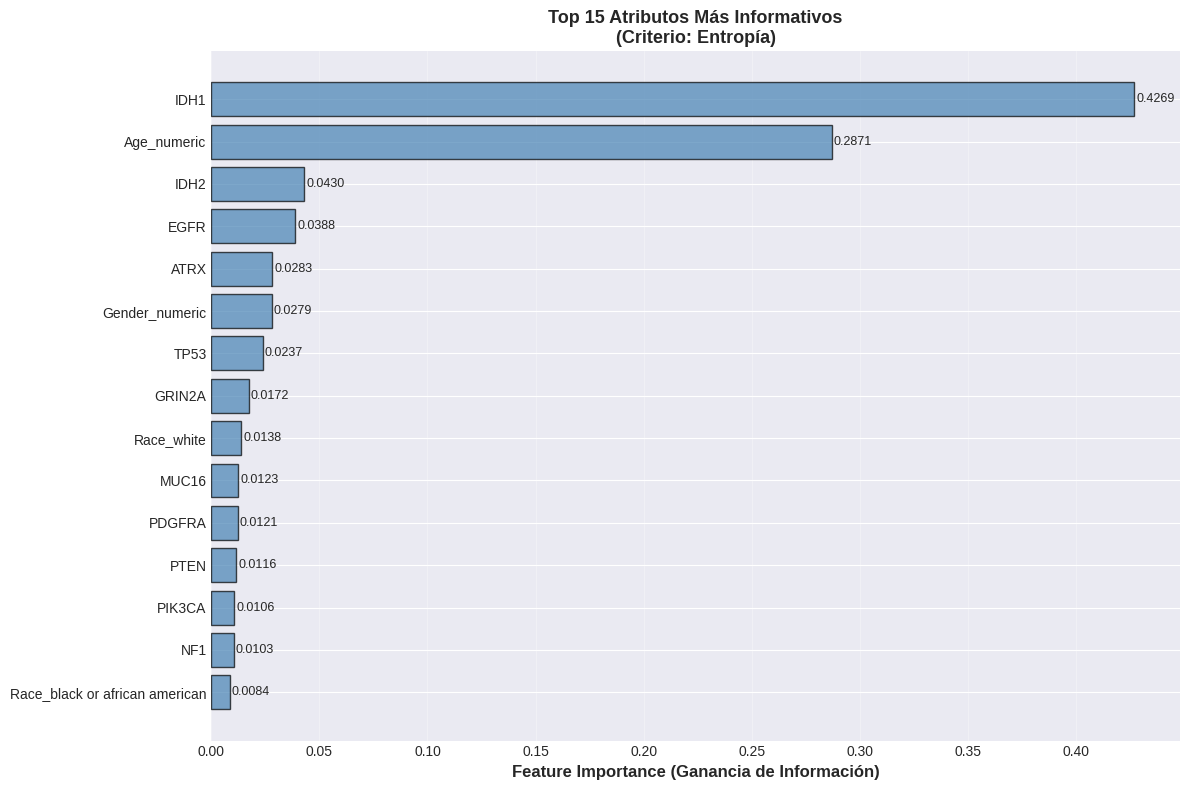


4. ANÁLISIS DE IMPORTANCIA:
  - Variables con importancia > 0: 23
  - Variables con importancia = 0 (no informativas): 5
  - Importancia acumulada Top 5: 0.8240
  - Importancia acumulada Top 15: 0.9720

5. CONCLUSIÓN:
  Los 23 atributos con importancia > 0 son los más informativos
  para discriminar entre LGG y GBM (según el criterio de ENTROPÍA del árbol)


In [144]:
# =============================================================================
# ATRIBUTOS MÁS INFORMATIVOS
# basada en entropía o Gini para seleccionar el mejor atributo.
# =============================================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

print("\n" + "="*80)
print("ATRIBUTOS MÁS INFORMATIVOS - Ganancia de Información")
print("="*80)

# Método 1: Usar Feature Importance de DecisionTreeClassifier
# El PDF usa DecisionTreeClassifier, que calcula información/gini internamente

# Convertir y a numérico para el modelo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Crear árbol sin limitar profundidad (para ver importancia de todas las variables)
# Basado en ejemplos del PDF
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_classifier.fit(X, y_encoded)

# Obtener feature importance (Information Gain normalizado)
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 15 variables más informativas (Feature Importance del Árbol):")
print(f"\n{'Rank':<6} {'Variable':<25} {'Importancia':>15} {'Porcentaje':>12}")
print("-" * 60)

for i, (idx, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    pct = (row['Importance'] / feature_importance['Importance'].sum()) * 100
    print(f"{i:<6} {row['Variable']:<25} {row['Importance']:>15.6f} {pct:>11.2f}%")

# Visualización: Gráfico de barras
plt.figure(figsize=(12, 8))

top_n = 15
top_features = feature_importance.head(top_n)

plt.barh(range(len(top_features)), top_features['Importance'].values,
         color='steelblue', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Variable'].values)
plt.xlabel('Feature Importance (Ganancia de Información)', fontsize=12, fontweight='bold')
plt.title('Top 15 Atributos Más Informativos\n(Criterio: Entropía)',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Agregar valores
for i, v in enumerate(top_features['Importance'].values):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Estadísticas
print(f"\n4. ANÁLISIS DE IMPORTANCIA:")
print(f"  - Variables con importancia > 0: {(feature_importance['Importance'] > 0).sum()}")
print(f"  - Variables con importancia = 0 (no informativas): {(feature_importance['Importance'] == 0).sum()}")
print(f"  - Importancia acumulada Top 5: {feature_importance.head(5)['Importance'].sum():.4f}")
print(f"  - Importancia acumulada Top 15: {feature_importance.head(15)['Importance'].sum():.4f}")

print(f"\n5. CONCLUSIÓN:")
print(f"  Los {(feature_importance['Importance'] > 0).sum()} atributos con importancia > 0 son los más informativos")
print(f"  para discriminar entre LGG y GBM (según el criterio de ENTROPÍA del árbol)")

# **3. Gráfica de Errores en Entrenamiento y Prueba**

**Preparación de datos y configuración**

In [145]:
# Convertir etiquetas de clases a valores numéricos
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("="*80)
print("ENTRENAMIENTO DE ÁRBOL DE DECISIÓN CON DIFERENTES PROFUNDIDADES")
print("="*80)

# Definir las profundidades a evaluar
max_depths = [2, 5, 10, 15, 20, 25, 30, None]

print(f"\nProfundidades a evaluar: {max_depths}")
print(f"Métrica: F1 Macro")
print(f"Número de particiones: 10 (StratifiedKFold)")

ENTRENAMIENTO DE ÁRBOL DE DECISIÓN CON DIFERENTES PROFUNDIDADES

Profundidades a evaluar: [2, 5, 10, 15, 20, 25, 30, None]
Métrica: F1 Macro
Número de particiones: 10 (StratifiedKFold)


**Configurar StratifiedKFold**

In [146]:
# Configurar StratifiedKFold con los parámetros especificados
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=3)

print(f"\nStratifiedKFold configurado:")
print(f"  - Particiones: 10")
print(f"  - Shuffle: True")
print(f"  - Random state: 3")
print(f"  - Mantiene proporciones de clases en cada fold")


StratifiedKFold configurado:
  - Particiones: 10
  - Shuffle: True
  - Random state: 3
  - Mantiene proporciones de clases en cada fold


**Entrenar y evaluar modelos con diferentes profundidades**

In [147]:
# Listas para almacenar los resultados
f1_scores = []
f1_means = []
f1_stds = []

print(f"\n{'Profundidad':<15} {'F1 Macro Mean':<20} {'F1 Macro Std':<20}")
print("-" * 60)

# Iterar sobre cada profundidad
for depth in max_depths:

    # Crear árbol de decisión con la profundidad actual
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Usar cross_val_score con los parámetros especificados
    scores = cross_val_score(dt, X, y_encoded, cv=skf, scoring='f1_macro')

    # Guardar los resultados
    f1_scores.append(scores)
    f1_means.append(scores.mean())
    f1_stds.append(scores.std())

    # Mostrar resultados para cada profundidad
    print(f"{str(depth):<15} {scores.mean():<20.6f} {scores.std():<20.6f}")

print("-" * 60)


Profundidad     F1 Macro Mean        F1 Macro Std        
------------------------------------------------------------
2               0.868982             0.026235            
5               0.861801             0.022829            
10              0.828569             0.026417            
15              0.796946             0.030818            
20              0.789301             0.040997            
25              0.797253             0.038466            
30              0.795908             0.038853            
None            0.795908             0.038853            
------------------------------------------------------------



**Crear DataFrame con los resultados**

In [148]:
# Crear un DataFrame con los resultados para mejor visualización
resultados = pd.DataFrame({
    'Profundidad': [str(d) if d is not None else 'None' for d in max_depths],
    'F1_Macro_Mean': f1_means,
    'F1_Macro_Std': f1_stds
})

print("\nResultados consolidados:")
print(resultados)

# Encontrar la mejor profundidad según F1 Macro
best_idx = np.argmax(f1_means)
best_depth = max_depths[best_idx]
best_score = f1_means[best_idx]

print(f"\nMejor profundidad: {best_depth}")
print(f"F1 Macro Score: {best_score:.6f}")


Resultados consolidados:
  Profundidad  F1_Macro_Mean  F1_Macro_Std
0           2       0.868982      0.026235
1           5       0.861801      0.022829
2          10       0.828569      0.026417
3          15       0.796946      0.030818
4          20       0.789301      0.040997
5          25       0.797253      0.038466
6          30       0.795908      0.038853
7        None       0.795908      0.038853

Mejor profundidad: 2
F1 Macro Score: 0.868982


**Graficar los resultados**

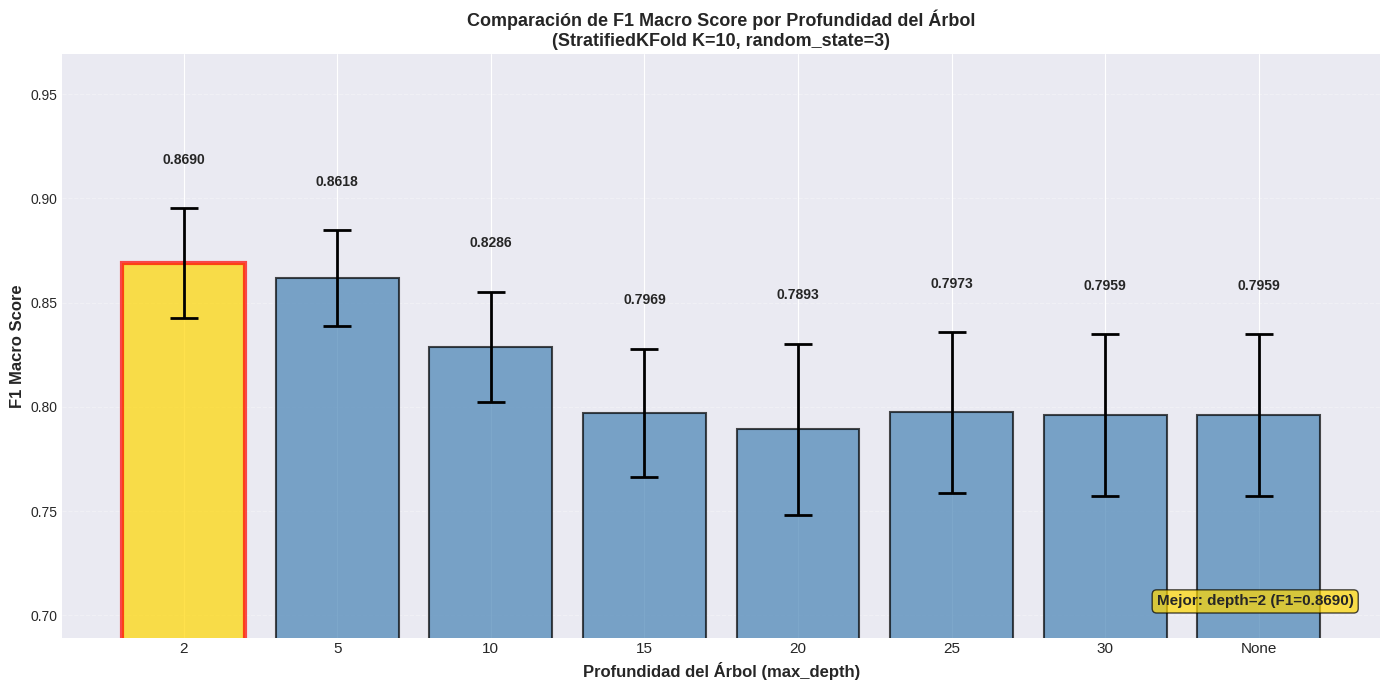

In [149]:
# Convertir profundidades a strings para mejor visualización en gráfico
profundidades_str = [str(d) if d is not None else 'None' for d in max_depths]
indices = np.arange(len(max_depths))

# Crear figura
plt.figure(figsize=(14, 7))

# Gráfico de barras con barras de error (desviación estándar)
bars = plt.bar(indices, f1_means, yerr=f1_stds, capsize=10,
               alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5,
               error_kw={'elinewidth': 2, 'capthick': 2})

# Resaltar la mejor barra
bars[best_idx].set_color('gold')
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

# Configurar el gráfico
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12, fontweight='bold')
plt.ylabel('F1 Macro Score', fontsize=12, fontweight='bold')
plt.title('Comparación de F1 Macro Score por Profundidad del Árbol\n(StratifiedKFold K=10, random_state=3)',
          fontsize=13, fontweight='bold')
plt.xticks(indices, profundidades_str, fontsize=11)
plt.ylim([min(f1_means) - 0.1, max(f1_means) + 0.1])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores en las barras
for i, (mean, std) in enumerate(zip(f1_means, f1_stds)):
    plt.text(i, mean + std + 0.02, f'{mean:.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Leyenda
plt.text(0.98, 0.05, f'Mejor: depth={best_depth} (F1={best_score:.4f})',
         transform=plt.gca().transAxes, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='gold', alpha=0.7),
         ha='right', va='bottom')

plt.tight_layout()
plt.show()

**Análisis de resultados**

In [150]:
# Análisis adicional
print("\n" + "="*80)
print("ANÁLISIS DE RESULTADOS")
print("="*80)

# Encontrar profundidad con mejor score y peor score
worst_idx = np.argmin(f1_means)
worst_depth = max_depths[worst_idx]

print(f"\nResumen de desempeño:")
print(f"  Mejor profundidad:  {best_depth} con F1 Macro = {best_score:.6f}")
print(f"  Peor profundidad:   {worst_depth} con F1 Macro = {f1_means[worst_idx]:.6f}")
print(f"  Diferencia:         {best_score - f1_means[worst_idx]:.6f}")

# Ordenar por mejor desempeño
top_3_idx = np.argsort(f1_means)[::-1][:3]

print(f"\nTop 3 profundidades con mejor F1 Macro:")
for rank, idx in enumerate(top_3_idx, 1):
    print(f"  {rank}. Profundidad {max_depths[idx]}: F1 = {f1_means[idx]:.6f} ± {f1_stds[idx]:.6f}")


ANÁLISIS DE RESULTADOS

Resumen de desempeño:
  Mejor profundidad:  2 con F1 Macro = 0.868982
  Peor profundidad:   20 con F1 Macro = 0.789301
  Diferencia:         0.079681

Top 3 profundidades con mejor F1 Macro:
  1. Profundidad 2: F1 = 0.868982 ± 0.026235
  2. Profundidad 5: F1 = 0.861801 ± 0.022829
  3. Profundidad 10: F1 = 0.828569 ± 0.026417


# **4. Optimización de hiperparámetros con RandomizedSearchCV**

**Definir el espacio de búsqueda aleatorio**

In [158]:
# Definir el espacio de búsqueda para cada hiperparámetro
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

print("="*80)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON RANDOMIZEDSEARCHCV")
print("="*80)

print(f"\nEspacio de búsqueda aleatorio definido:")
print(f"  - Criterion: {param_dist['criterion']}")
print(f"  - Max_depth: 5 a 50 (rango continuo)")
print(f"  - Min_samples_split: 2 a 20 (rango continuo)")

# Calcular número total de combinaciones posibles
total_combinations = len(param_dist['criterion']) * len(param_dist['max_depth']) * len(param_dist['min_samples_split'])
print(f"\nTotal de combinaciones posibles en el espacio: {total_combinations}")
print(f"Combinaciones a evaluar (n_iter): 5")
print(f"Porcentaje del espacio explorado: {(5/total_combinations)*100:.4f}%")

OPTIMIZACIÓN DE HIPERPARÁMETROS CON RANDOMIZEDSEARCHCV

Espacio de búsqueda aleatorio definido:
  - Criterion: ['gini', 'entropy']
  - Max_depth: 5 a 50 (rango continuo)
  - Min_samples_split: 2 a 20 (rango continuo)

Total de combinaciones posibles en el espacio: 1748
Combinaciones a evaluar (n_iter): 5
Porcentaje del espacio explorado: 0.2860%


**Configurar RandomizedSearchCV**

In [159]:
# Crear el árbol de decisión base
dt = DecisionTreeClassifier(random_state=42)

# Configurar StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Convertir y a numérico
y_encoded = le.fit_transform(y)

# Crear RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=5,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print(f"\nRandomizedSearchCV configurado:")
print(f"  - StratifiedKFold: 10 particiones")
print(f"  - n_iter: 5 (combinaciones aleatorias)")
print(f"  - Métrica: f1_macro")
print(f"  - n_jobs: -1 (usar todos los procesadores)")
print(f"  - Random state: 42 (reproducibilidad)")
print(f"  - Verbose: 1 (mostrar progreso)")


RandomizedSearchCV configurado:
  - StratifiedKFold: 10 particiones
  - n_iter: 5 (combinaciones aleatorias)
  - Métrica: f1_macro
  - n_jobs: -1 (usar todos los procesadores)
  - Random state: 42 (reproducibilidad)
  - Verbose: 1 (mostrar progreso)


**Ejecutar la búsqueda aleatoria de hiperparámetros**

In [160]:
# Ejecutar la búsqueda
print(f"\nEjecutando búsqueda aleatoria de hiperparámetros...")
print(f"Evaluando 5 combinaciones aleatorias...")

random_search.fit(X, y_encoded)

print(f"\n✅ Búsqueda completada")


Ejecutando búsqueda aleatoria de hiperparámetros...
Evaluando 5 combinaciones aleatorias...
Fitting 10 folds for each of 5 candidates, totalling 50 fits

✅ Búsqueda completada


**Mostrar los mejores hiperparámetros**

In [161]:
# Obtener los mejores parámetros
best_params_random = random_search.best_params_

print("\n" + "="*80)
print("RESULTADOS DE LA OPTIMIZACIÓN (RANDOMIZEDSEARCHCV)")
print("="*80)

print(f"\nMEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"\n  - Criterion:           {best_params_random['criterion']}")
print(f"  - Max_depth:           {best_params_random['max_depth']}")
print(f"  - Min_samples_split:   {best_params_random['min_samples_split']}")

# Obtener el mejor score
best_score_random = random_search.best_score_

print(f"\nMEJOR F1 MACRO SCORE:  {best_score_random:.6f}")

# Información adicional
print(f"\nNúmero de modelos evaluados: {len(random_search.cv_results_['params'])}")


RESULTADOS DE LA OPTIMIZACIÓN (RANDOMIZEDSEARCHCV)

MEJORES HIPERPARÁMETROS ENCONTRADOS:

  - Criterion:           entropy
  - Max_depth:           35
  - Min_samples_split:   17

MEJOR F1 MACRO SCORE:  0.832926

Número de modelos evaluados: 5


**Análisis detallado de resultados**

In [162]:
# Crear DataFrame con los resultados
resultados_random = pd.DataFrame(random_search.cv_results_)

# Seleccionar columnas relevantes
columnas_relevantes = ['param_criterion', 'param_max_depth', 'param_min_samples_split',
                       'mean_test_score', 'std_test_score', 'rank_test_score']
resultados_df_random = resultados_random[columnas_relevantes].copy()

# Ordenar por rank (mejores primero)
resultados_df_random = resultados_df_random.sort_values('rank_test_score')

print(f"\nResultados de las 5 combinaciones evaluadas:")
print(f"\n{'Rank':<6} {'Criterion':<12} {'Max_Depth':<12} {'Min_Split':<12} {'F1 Score':<12} {'±Std':<12}")
print("-" * 75)

for idx, row in resultados_df_random.iterrows():
    print(f"{int(row['rank_test_score']):<6} {row['param_criterion']:<12} "
          f"{int(row['param_max_depth']):<12} {int(row['param_min_samples_split']):<12} "
          f"{row['mean_test_score']:<12.6f} {row['std_test_score']:<12.6f}")

print("="*80)


Resultados de las 5 combinaciones evaluadas:

Rank   Criterion    Max_Depth    Min_Split    F1 Score     ±Std        
---------------------------------------------------------------------------
1      entropy      35           17           0.832926     0.024421    
2      entropy      18           7            0.818863     0.029910    
3      gini         50           7            0.818225     0.033927    
4      entropy      18           11           0.817680     0.029316    
5      entropy      27           4            0.810384     0.036651    


# **5. Optimización de hiperparámetros con GridSearchCV**

**Definir el espacio de búsqueda de hiperparámetros**

In [151]:
# Definir el espacio de búsqueda para cada hiperparámetro
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(5, 51),
    'min_samples_split': range(2, 21)
}

print("="*80)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV")
print("="*80)

print(f"\nEspacio de búsqueda definido:")
print(f"  - Criterion: {param_grid['criterion']}")
print(f"  - Max_depth: 5 a 50 (incrementos de 1)")
print(f"  - Min_samples_split: 2 a 20 (incrementos de 1)")

# Calcular número total de combinaciones
total_combinations = len(param_grid['criterion']) * len(list(param_grid['max_depth'])) * len(list(param_grid['min_samples_split']))
print(f"\nTotal de combinaciones a evaluar: {total_combinations}")

OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV

Espacio de búsqueda definido:
  - Criterion: ['gini', 'entropy']
  - Max_depth: 5 a 50 (incrementos de 1)
  - Min_samples_split: 2 a 20 (incrementos de 1)

Total de combinaciones a evaluar: 1748


**Configurar GridSearchCV**

In [152]:
# Crear el árbol de decisión base
dt = DecisionTreeClassifier(random_state=42)

# Configurar StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Convertir y a numérico (si aún no está convertido)
y_encoded = le.fit_transform(y)

# Crear GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print(f"\nGridSearchCV configurado:")
print(f"  - StratifiedKFold: 10 particiones")
print(f"  - Métrica: f1_macro")
print(f"  - n_jobs: -1 (usar todos los procesadores)")
print(f"  - Verbose: 1 (mostrar progreso)")


GridSearchCV configurado:
  - StratifiedKFold: 10 particiones
  - Métrica: f1_macro
  - n_jobs: -1 (usar todos los procesadores)
  - Verbose: 1 (mostrar progreso)


**Ejecutar la búsqueda de hiperparámetros**

In [153]:
# Ejecutar la búsqueda
print(f"\nEjecutando búsqueda de hiperparámetros...")
print(f"Esto puede tomar un tiempo debido al alto número de combinaciones...")

grid_search.fit(X, y_encoded)

print(f"\n✅ Búsqueda completada")


Ejecutando búsqueda de hiperparámetros...
Esto puede tomar un tiempo debido al alto número de combinaciones...
Fitting 10 folds for each of 1748 candidates, totalling 17480 fits

✅ Búsqueda completada


**Mostrar los mejores hiperparámetros**

In [154]:
# Obtener los mejores parámetros
best_params = grid_search.best_params_

print("\n" + "="*80)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*80)

print(f"\nMEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"\n  - Criterion:           {best_params['criterion']}")
print(f"  - Max_depth:           {best_params['max_depth']}")
print(f"  - Min_samples_split:   {best_params['min_samples_split']}")

# Obtener el mejor score
best_score = grid_search.best_score_

print(f"\n📊 MEJOR F1 MACRO SCORE:  {best_score:.6f}")

# Información adicional
print(f"\nNúmero de modelos evaluados: {len(grid_search.cv_results_['params'])}")


RESULTADOS DE LA OPTIMIZACIÓN

MEJORES HIPERPARÁMETROS ENCONTRADOS:

  - Criterion:           gini
  - Max_depth:           6
  - Min_samples_split:   14

📊 MEJOR F1 MACRO SCORE:  0.872554

Número de modelos evaluados: 1748


**Análisis detallado de resultados**

In [155]:
# Crear DataFrame con los resultados
resultados_grid = pd.DataFrame(grid_search.cv_results_)

# Seleccionar columnas relevantes
columnas_relevantes = ['param_criterion', 'param_max_depth', 'param_min_samples_split',
                       'mean_test_score', 'std_test_score', 'rank_test_score']
resultados_df = resultados_grid[columnas_relevantes].copy()

# Ordenar por rank (mejores primero)
resultados_df = resultados_df.sort_values('rank_test_score')

print(f"\nTop 10 mejores combinaciones de hiperparámetros:")
print(f"\n{'Rank':<6} {'Criterion':<12} {'Max_Depth':<12} {'Min_Split':<12} {'F1 Score':<12} {'±Std':<12}")
print("-" * 75)

for idx, row in resultados_df.head(10).iterrows():
    print(f"{int(row['rank_test_score']):<6} {row['param_criterion']:<12} "
          f"{int(row['param_max_depth']):<12} {int(row['param_min_samples_split']):<12} "
          f"{row['mean_test_score']:<12.6f} {row['std_test_score']:<12.6f}")

print("="*80)


Top 10 mejores combinaciones de hiperparámetros:

Rank   Criterion    Max_Depth    Min_Split    F1 Score     ±Std        
---------------------------------------------------------------------------
1      gini         6            15           0.872554     0.032259    
1      gini         6            17           0.872554     0.032259    
1      gini         6            18           0.872554     0.032259    
1      gini         6            20           0.872554     0.032259    
1      gini         6            14           0.872554     0.032259    
1      gini         6            16           0.872554     0.032259    
1      gini         6            19           0.872554     0.032259    
8      gini         6            8            0.869149     0.031928    
8      gini         6            5            0.869149     0.031928    
8      gini         6            6            0.869149     0.031928    


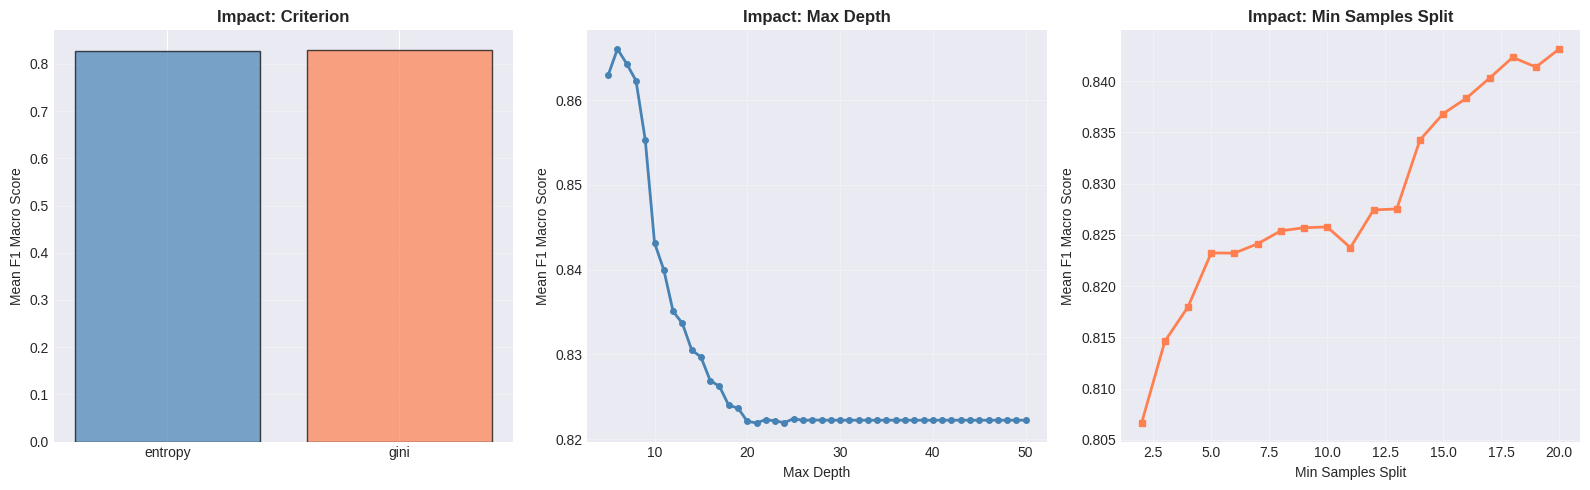

In [157]:
# Gráfico: Impact de cada hiperparámetro en el F1 Score

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Impact de criterion
criterion_impact = resultados_grid.groupby('param_criterion')['mean_test_score'].mean()
axes[0].bar(criterion_impact.index, criterion_impact.values, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[0].set_title('Impact: Criterion', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean F1 Macro Score', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Impact de max_depth
max_depth_impact = resultados_grid.groupby('param_max_depth')['mean_test_score'].mean()
axes[1].plot(max_depth_impact.index, max_depth_impact.values, 'o-', color='steelblue', linewidth=2, markersize=4)
axes[1].set_title('Impact: Max Depth', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Max Depth', fontsize=10)
axes[1].set_ylabel('Mean F1 Macro Score', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Impact de min_samples_split
min_split_impact = resultados_grid.groupby('param_min_samples_split')['mean_test_score'].mean()
axes[2].plot(min_split_impact.index, min_split_impact.values, 's-', color='coral', linewidth=2, markersize=4)
axes[2].set_title('Impact: Min Samples Split', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Min Samples Split', fontsize=10)
axes[2].set_ylabel('Mean F1 Macro Score', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Comparación entre GridSearchCV y RandomizedSearchCV**

In [164]:
print("\n" + "="*80)
print("COMPARACIÓN: GRIDSEARCHCV vs RANDOMIZEDSEARCHCV")
print("="*80)

print(f"\nGridSearchCV (Búsqueda exhaustiva):")
print(f"  - Best F1 Score: {best_score:.6f}")
print(f"  - Best Criterion: {best_params['criterion']}")
print(f"  - Best Max_depth: {best_params['max_depth']}")
print(f"  - Best Min_samples_split: {best_params['min_samples_split']}")
print(f"  - Modelos evaluados: {len(grid_search.cv_results_['params'])}")

print(f"\nRandomizedSearchCV (Búsqueda aleatoria):")
print(f"  - Best F1 Score: {best_score_random:.6f}")
print(f"  - Best Criterion: {best_params_random['criterion']}")
print(f"  - Best Max_depth: {best_params_random['max_depth']}")
print(f"  - Best Min_samples_split: {best_params_random['min_samples_split']}")
print(f"  - Modelos evaluados: {len(random_search.cv_results_['params'])}")

print(f"\nAnálisis:")
diferencia_score = best_score - best_score_random
reduccion_modelos = ((len(grid_search.cv_results_['params']) - len(random_search.cv_results_['params'])) / len(grid_search.cv_results_['params'])) * 100

print(f"  - Diferencia de F1 Score: {diferencia_score:.6f}")
print(f"  - Reducción de modelos evaluados: {reduccion_modelos:.2f}%")

if abs(diferencia_score) < 0.01:
    print(f"  - Conclusión: RandomizedSearchCV es más eficiente con resultados similares")
else:
    print(f"  - Conclusión: GridSearchCV encontró mejores parámetros (diferencia: {diferencia_score:.6f})")

print("="*80)


COMPARACIÓN: GRIDSEARCHCV vs RANDOMIZEDSEARCHCV

GridSearchCV (Búsqueda exhaustiva):
  - Best F1 Score: 0.872554
  - Best Criterion: gini
  - Best Max_depth: 6
  - Best Min_samples_split: 14
  - Modelos evaluados: 1748

RandomizedSearchCV (Búsqueda aleatoria):
  - Best F1 Score: 0.832926
  - Best Criterion: entropy
  - Best Max_depth: 35
  - Best Min_samples_split: 17
  - Modelos evaluados: 5

Análisis:
  - Diferencia de F1 Score: 0.039627
  - Reducción de modelos evaluados: 99.71%
  - Conclusión: GridSearchCV encontró mejores parámetros (diferencia: 0.039627)


# **6. Optimización de hiperparámetros con RandomizedSearchCV: Accuracy**

**Definir el espacio de búsqueda aleatorio**

In [165]:
# Definir el espacio de búsqueda para cada hiperparámetro
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

print("="*80)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON RANDOMIZEDSEARCHCV - ACCURACY")
print("="*80)

print(f"\nEspacio de búsqueda aleatorio definido:")
print(f"  - Criterion: {param_dist['criterion']}")
print(f"  - Max_depth: 5 a 50 (rango continuo)")
print(f"  - Min_samples_split: 2 a 20 (rango continuo)")

# Calcular número total de combinaciones posibles
total_combinations = len(param_dist['criterion']) * len(param_dist['max_depth']) * len(param_dist['min_samples_split'])
print(f"\nTotal de combinaciones posibles en el espacio: {total_combinations}")
print(f"Combinaciones a evaluar (n_iter): 5")
print(f"Porcentaje del espacio explorado: {(5/total_combinations)*100:.4f}%")

OPTIMIZACIÓN DE HIPERPARÁMETROS CON RANDOMIZEDSEARCHCV - ACCURACY

Espacio de búsqueda aleatorio definido:
  - Criterion: ['gini', 'entropy']
  - Max_depth: 5 a 50 (rango continuo)
  - Min_samples_split: 2 a 20 (rango continuo)

Total de combinaciones posibles en el espacio: 1748
Combinaciones a evaluar (n_iter): 5
Porcentaje del espacio explorado: 0.2860%


**Configurar RandomizedSearchCV con accuracy**

In [166]:
# Crear el árbol de decisión base
dt = DecisionTreeClassifier(random_state=42)

# Configurar StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Convertir y a numérico
y_encoded = le.fit_transform(y)

# Crear RandomizedSearchCV con scoring='accuracy'
random_search_acc = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=5,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print(f"\nRandomizedSearchCV configurado:")
print(f"  - StratifiedKFold: 10 particiones")
print(f"  - n_iter: 5 (combinaciones aleatorias)")
print(f"  - Métrica: accuracy")
print(f"  - n_jobs: -1 (usar todos los procesadores)")
print(f"  - Random state: 42 (reproducibilidad)")
print(f"  - Verbose: 1 (mostrar progreso)")


RandomizedSearchCV configurado:
  - StratifiedKFold: 10 particiones
  - n_iter: 5 (combinaciones aleatorias)
  - Métrica: accuracy
  - n_jobs: -1 (usar todos los procesadores)
  - Random state: 42 (reproducibilidad)
  - Verbose: 1 (mostrar progreso)


**Ejecutar la búsqueda aleatoria**

In [167]:
# Ejecutar la búsqueda
print(f"\nEjecutando búsqueda aleatoria de hiperparámetros con ACCURACY...")
print(f"Evaluando 5 combinaciones aleatorias...")

random_search_acc.fit(X, y_encoded)

print(f"\n✅ Búsqueda completada")


Ejecutando búsqueda aleatoria de hiperparámetros con ACCURACY...
Evaluando 5 combinaciones aleatorias...
Fitting 10 folds for each of 5 candidates, totalling 50 fits

✅ Búsqueda completada


**Mostrar los mejores hiperparámetros**

In [168]:
# Obtener los mejores parámetros
best_params_acc = random_search_acc.best_params_

print("\n" + "="*80)
print("RESULTADOS DE LA OPTIMIZACIÓN (RANDOMIZEDSEARCHCV - ACCURACY)")
print("="*80)

print(f"\nMEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"\n  - Criterion:           {best_params_acc['criterion']}")
print(f"  - Max_depth:           {best_params_acc['max_depth']}")
print(f"  - Min_samples_split:   {best_params_acc['min_samples_split']}")

# Obtener el mejor score
best_score_acc = random_search_acc.best_score_

print(f"\nMEJOR ACCURACY SCORE:  {best_score_acc:.6f}")

# Información adicional
print(f"\nNúmero de modelos evaluados: {len(random_search_acc.cv_results_['params'])}")


RESULTADOS DE LA OPTIMIZACIÓN (RANDOMIZEDSEARCHCV - ACCURACY)

MEJORES HIPERPARÁMETROS ENCONTRADOS:

  - Criterion:           entropy
  - Max_depth:           35
  - Min_samples_split:   17

MEJOR ACCURACY SCORE:  0.836474

Número de modelos evaluados: 5


**Análisis detallado de resultados**

In [169]:
# Crear DataFrame con los resultados
resultados_acc = pd.DataFrame(random_search_acc.cv_results_)

# Seleccionar columnas relevantes
columnas_relevantes = ['param_criterion', 'param_max_depth', 'param_min_samples_split',
                       'mean_test_score', 'std_test_score', 'rank_test_score']
resultados_df_acc = resultados_acc[columnas_relevantes].copy()

# Ordenar por rank (mejores primero)
resultados_df_acc = resultados_df_acc.sort_values('rank_test_score')

print(f"\nResultados de las 5 combinaciones evaluadas (ACCURACY):")
print(f"\n{'Rank':<6} {'Criterion':<12} {'Max_Depth':<12} {'Min_Split':<12} {'Accuracy':<12} {'±Std':<12}")
print("-" * 75)

for idx, row in resultados_df_acc.iterrows():
    print(f"{int(row['rank_test_score']):<6} {row['param_criterion']:<12} "
          f"{int(row['param_max_depth']):<12} {int(row['param_min_samples_split']):<12} "
          f"{row['mean_test_score']:<12.6f} {row['std_test_score']:<12.6f}")

print("="*80)


Resultados de las 5 combinaciones evaluadas (ACCURACY):

Rank   Criterion    Max_Depth    Min_Split    Accuracy     ±Std        
---------------------------------------------------------------------------
1      entropy      35           17           0.836474     0.024706    
2      entropy      18           7            0.822534     0.029574    
3      gini         50           7            0.822494     0.032726    
4      entropy      18           11           0.821371     0.029200    
5      entropy      27           4            0.814408     0.036053    


**Comparación de métricas F1 Macro vs Accuracy**

In [170]:
print("\n" + "="*80)
print("COMPARACIÓN: F1 MACRO vs ACCURACY")
print("="*80)

print(f"\nRandomizedSearchCV con F1 MACRO:")
print(f"  - Best Score: {best_score_random:.6f}")
print(f"  - Best Criterion: {best_params_random['criterion']}")
print(f"  - Best Max_depth: {best_params_random['max_depth']}")
print(f"  - Best Min_samples_split: {best_params_random['min_samples_split']}")

print(f"\nRandomizedSearchCV con ACCURACY:")
print(f"  - Best Score: {best_score_acc:.6f}")
print(f"  - Best Criterion: {best_params_acc['criterion']}")
print(f"  - Best Max_depth: {best_params_acc['max_depth']}")
print(f"  - Best Min_samples_split: {best_params_acc['min_samples_split']}")

print(f"\nAnálisis:")
diferencia_score = best_score_acc - best_score_random
print(f"  - Diferencia de Score (Accuracy - F1 Macro): {diferencia_score:.6f}")

if best_params_acc == best_params_random:
    print(f"  - Conclusión: Ambas métricas encontraron los mismos hiperparámetros")
else:
    print(f"  - Conclusión: Las métricas encontraron hiperparámetros diferentes")
    print(f"    F1 Macro es mejor para clases desbalanceadas")
    print(f"    Accuracy es mejor para clases balanceadas")

print("="*80)



COMPARACIÓN: F1 MACRO vs ACCURACY

RandomizedSearchCV con F1 MACRO:
  - Best Score: 0.832926
  - Best Criterion: entropy
  - Best Max_depth: 35
  - Best Min_samples_split: 17

RandomizedSearchCV con ACCURACY:
  - Best Score: 0.836474
  - Best Criterion: entropy
  - Best Max_depth: 35
  - Best Min_samples_split: 17

Análisis:
  - Diferencia de Score (Accuracy - F1 Macro): 0.003548
  - Conclusión: Ambas métricas encontraron los mismos hiperparámetros


# **7. Optimización de hiperparámetros con GridSearchCV: accuracy**

**Definir el espacio de búsqueda exhaustivo**

In [171]:
# Definir el espacio de búsqueda para cada hiperparámetro
param_grid_f1 = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(5, 51),
    'min_samples_split': range(2, 21)
}

print("="*80)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV - F1 MACRO")
print("="*80)

print(f"\nEspacio de búsqueda exhaustivo definido:")
print(f"  - Criterion: {list(param_grid_f1['criterion'])}")
print(f"  - Max_depth: 5 a 50 (incrementos de 1)")
print(f"  - Min_samples_split: 2 a 20 (incrementos de 1)")

# Calcular número total de combinaciones
total_combinations_f1 = len(param_grid_f1['criterion']) * len(list(param_grid_f1['max_depth'])) * len(list(param_grid_f1['min_samples_split']))
print(f"\nTotal de combinaciones a evaluar: {total_combinations_f1}")

OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV - F1 MACRO

Espacio de búsqueda exhaustivo definido:
  - Criterion: ['gini', 'entropy']
  - Max_depth: 5 a 50 (incrementos de 1)
  - Min_samples_split: 2 a 20 (incrementos de 1)

Total de combinaciones a evaluar: 1748


**Configurar GridSearchCV con f1_macro**

In [172]:
# Crear el árbol de decisión base
dt = DecisionTreeClassifier(random_state=42)

# Configurar StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Convertir y a numérico
y_encoded = le.fit_transform(y)

# Crear GridSearchCV con scoring='f1_macro'
grid_search_f1 = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_f1,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print(f"\nGridSearchCV configurado:")
print(f"  - StratifiedKFold: 10 particiones")
print(f"  - Métrica: f1_macro")
print(f"  - n_jobs: -1 (usar todos los procesadores)")
print(f"  - Verbose: 1 (mostrar progreso)")


GridSearchCV configurado:
  - StratifiedKFold: 10 particiones
  - Métrica: f1_macro
  - n_jobs: -1 (usar todos los procesadores)
  - Verbose: 1 (mostrar progreso)


**Ejecutar la búsqueda exhaustiva de hiperparámetros**

In [173]:
# Ejecutar la búsqueda
print(f"\nEjecutando búsqueda exhaustiva de hiperparámetros...")
print(f"Esto puede tomar un tiempo debido al alto número de combinaciones...")

grid_search_f1.fit(X, y_encoded)

print(f"\n✅ Búsqueda completada")


Ejecutando búsqueda exhaustiva de hiperparámetros...
Esto puede tomar un tiempo debido al alto número de combinaciones...
Fitting 10 folds for each of 1748 candidates, totalling 17480 fits

✅ Búsqueda completada


**Mostrar los mejores hiperparámetros**

In [174]:
# Obtener los mejores parámetros
best_params_f1 = grid_search_f1.best_params_

print("\n" + "="*80)
print("RESULTADOS DE LA OPTIMIZACIÓN (GRIDSEARCHCV - F1 MACRO)")
print("="*80)

print(f"\nMEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"\n  - Criterion:           {best_params_f1['criterion']}")
print(f"  - Max_depth:           {best_params_f1['max_depth']}")
print(f"  - Min_samples_split:   {best_params_f1['min_samples_split']}")

# Obtener el mejor score
best_score_f1 = grid_search_f1.best_score_

print(f"\n📊 MEJOR F1 MACRO SCORE:  {best_score_f1:.6f}")

# Información adicional
print(f"\nNúmero de modelos evaluados: {len(grid_search_f1.cv_results_['params'])}")


RESULTADOS DE LA OPTIMIZACIÓN (GRIDSEARCHCV - F1 MACRO)

MEJORES HIPERPARÁMETROS ENCONTRADOS:

  - Criterion:           gini
  - Max_depth:           6
  - Min_samples_split:   14

📊 MEJOR F1 MACRO SCORE:  0.872554

Número de modelos evaluados: 1748


**Análisis detallado de resultados**

In [175]:
# Crear DataFrame con los resultados
resultados_grid_f1 = pd.DataFrame(grid_search_f1.cv_results_)

# Seleccionar columnas relevantes
columnas_relevantes = ['param_criterion', 'param_max_depth', 'param_min_samples_split',
                       'mean_test_score', 'std_test_score', 'rank_test_score']
resultados_df_f1 = resultados_grid_f1[columnas_relevantes].copy()

# Ordenar por rank (mejores primero)
resultados_df_f1 = resultados_df_f1.sort_values('rank_test_score')

print(f"\nTop 10 mejores combinaciones de hiperparámetros:")
print(f"\n{'Rank':<6} {'Criterion':<12} {'Max_Depth':<12} {'Min_Split':<12} {'F1 Score':<12} {'±Std':<12}")
print("-" * 75)

for idx, row in resultados_df_f1.head(10).iterrows():
    print(f"{int(row['rank_test_score']):<6} {row['param_criterion']:<12} "
          f"{int(row['param_max_depth']):<12} {int(row['param_min_samples_split']):<12} "
          f"{row['mean_test_score']:<12.6f} {row['std_test_score']:<12.6f}")

print("="*80)


Top 10 mejores combinaciones de hiperparámetros:

Rank   Criterion    Max_Depth    Min_Split    F1 Score     ±Std        
---------------------------------------------------------------------------
1      gini         6            15           0.872554     0.032259    
1      gini         6            17           0.872554     0.032259    
1      gini         6            18           0.872554     0.032259    
1      gini         6            20           0.872554     0.032259    
1      gini         6            14           0.872554     0.032259    
1      gini         6            16           0.872554     0.032259    
1      gini         6            19           0.872554     0.032259    
8      gini         6            8            0.869149     0.031928    
8      gini         6            5            0.869149     0.031928    
8      gini         6            6            0.869149     0.031928    


**Comparación GridSearchCV vs RandomizedSearchCV (F1 MACRO)**

In [176]:
print("\n" + "="*80)
print("COMPARACIÓN: GRIDSEARCHCV vs RANDOMIZEDSEARCHCV (F1 MACRO)")
print("="*80)

print(f"\nGridSearchCV (Búsqueda exhaustiva):")
print(f"  - Best F1 Score: {best_score_f1:.6f}")
print(f"  - Best Criterion: {best_params_f1['criterion']}")
print(f"  - Best Max_depth: {best_params_f1['max_depth']}")
print(f"  - Best Min_samples_split: {best_params_f1['min_samples_split']}")
print(f"  - Modelos evaluados: {len(grid_search_f1.cv_results_['params'])}")

print(f"\nRandomizedSearchCV (Búsqueda aleatoria - 5 iteraciones):")
print(f"  - Best F1 Score: {best_score_random:.6f}")
print(f"  - Best Criterion: {best_params_random['criterion']}")
print(f"  - Best Max_depth: {best_params_random['max_depth']}")
print(f"  - Best Min_samples_split: {best_params_random['min_samples_split']}")
print(f"  - Modelos evaluados: {len(random_search.cv_results_['params'])}")

print(f"\nAnálisis:")
diferencia_f1 = best_score_f1 - best_score_random
reduccion_modelos_f1 = ((len(grid_search_f1.cv_results_['params']) - len(random_search.cv_results_['params'])) / len(grid_search_f1.cv_results_['params'])) * 100

print(f"  - Diferencia de F1 Score: {diferencia_f1:.6f}")
print(f"  - Reducción de modelos evaluados: {reduccion_modelos_f1:.2f}%")

if abs(diferencia_f1) < 0.01:
    print(f"  - Conclusión: RandomizedSearchCV es más eficiente con resultados similares")
elif diferencia_f1 > 0:
    print(f"  - Conclusión: GridSearchCV encontró mejores parámetros")
else:
    print(f"  - Conclusión: RandomizedSearchCV encontró mejores parámetros")

print("="*80)


COMPARACIÓN: GRIDSEARCHCV vs RANDOMIZEDSEARCHCV (F1 MACRO)

GridSearchCV (Búsqueda exhaustiva):
  - Best F1 Score: 0.872554
  - Best Criterion: gini
  - Best Max_depth: 6
  - Best Min_samples_split: 14
  - Modelos evaluados: 1748

RandomizedSearchCV (Búsqueda aleatoria - 5 iteraciones):
  - Best F1 Score: 0.832926
  - Best Criterion: entropy
  - Best Max_depth: 35
  - Best Min_samples_split: 17
  - Modelos evaluados: 5

Análisis:
  - Diferencia de F1 Score: 0.039627
  - Reducción de modelos evaluados: 99.71%
  - Conclusión: GridSearchCV encontró mejores parámetros


# **8.Actividad de reflexión y análisis**

# *¿Cuál método encontró mejores hiperparámetros?*

In [177]:
print("="*80)
print("COMPARACIÓN DE TODOS LOS MÉTODOS DE OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*80)

# Crear tabla comparativa
comparacion = {
    'Método': [
        'GridSearchCV (F1 Macro)',
        'RandomizedSearchCV (F1 Macro - 5 iter)',
        'RandomizedSearchCV (Accuracy - 5 iter)',
        'GridSearchCV (Accuracy)'
    ],
    'Best_Score': [
        best_score_f1,
        best_score_random,
        best_score_acc,
        grid_search.best_score_  # El anterior de accuracy con GridSearchCV
    ],
    'Criterion': [
        best_params_f1['criterion'],
        best_params_random['criterion'],
        best_params_acc['criterion'],
        best_params['criterion']
    ],
    'Max_Depth': [
        best_params_f1['max_depth'],
        best_params_random['max_depth'],
        best_params_acc['max_depth'],
        best_params['max_depth']
    ],
    'Min_Samples_Split': [
        best_params_f1['min_samples_split'],
        best_params_random['min_samples_split'],
        best_params_acc['min_samples_split'],
        best_params['min_samples_split']
    ],
    'Modelos_Evaluados': [
        len(grid_search_f1.cv_results_['params']),
        5,
        5,
        len(grid_search.cv_results_['params'])
    ],
    'Metrica': [
        'F1 Macro',
        'F1 Macro',
        'Accuracy',
        'Accuracy'
    ]
}

df_comparacion = pd.DataFrame(comparacion)

print("\n📊 TABLA COMPARATIVA:")
print(df_comparacion.to_string(index=False))

print("\n" + "="*80)
print("ANÁLISIS DETALLADO")
print("="*80)

# 1. Mejor F1 Macro
mejor_f1_idx = comparacion['Best_Score'][:2].index(max(comparacion['Best_Score'][:2]))
mejor_f1_metodo = comparacion['Método'][mejor_f1_idx]

print(f"\n1️⃣  MEJOR MÉTODO PARA F1 MACRO:")
print(f"   Método: {mejor_f1_metodo}")
print(f"   Score: {comparacion['Best_Score'][mejor_f1_idx]:.6f}")

# 2. Mejor Accuracy
mejor_acc_idx = 2 + comparacion['Best_Score'][2:].index(max(comparacion['Best_Score'][2:]))
mejor_acc_metodo = comparacion['Método'][mejor_acc_idx]

print(f"\n2️⃣  MEJOR MÉTODO PARA ACCURACY:")
print(f"   Método: {mejor_acc_metodo}")
print(f"   Score: {comparacion['Best_Score'][mejor_acc_idx]:.6f}")

# 3. Eficiencia
print(f"\n3️⃣  EFICIENCIA (Modelos evaluados):")
print(f"   GridSearchCV (F1): {comparacion['Modelos_Evaluados'][0]} combinaciones")
print(f"   RandomizedSearchCV (F1): {comparacion['Modelos_Evaluados'][1]} combinaciones")
print(f"   GridSearchCV (Accuracy): {comparacion['Modelos_Evaluados'][3]} combinaciones")
print(f"   → RandomizedSearchCV es {(comparacion['Modelos_Evaluados'][0]/comparacion['Modelos_Evaluados'][1]):.1f}x más rápido")

# 4. Respuesta final
print("\n" + "="*80)
print("RESPUESTA: ¿CUÁL MÉTODO ENCONTRÓ MEJORES HIPERPARÁMETROS?")
print("="*80)

mejor_score_general = max(comparacion['Best_Score'])
mejor_metodo_general = comparacion['Método'][comparacion['Best_Score'].index(mejor_score_general)]
mejor_idx_general = comparacion['Best_Score'].index(mejor_score_general)

print(f"\n✅ GANADOR: {mejor_metodo_general}")
print(f"\n   Hiperparámetros óptimos:")
print(f"   - Criterion:           {comparacion['Criterion'][mejor_idx_general]}")
print(f"   - Max_depth:           {comparacion['Max_Depth'][mejor_idx_general]}")
print(f"   - Min_samples_split:   {comparacion['Min_Samples_Split'][mejor_idx_general]}")
print(f"\n   Score logrado: {mejor_score_general:.6f}")
print(f"   Modelos evaluados: {comparacion['Modelos_Evaluados'][mejor_idx_general]}")

# 5. Análisis comparativo
print(f"\n📈 ANÁLISIS COMPARATIVO:")

# Comparar GridSearchCV vs RandomizedSearchCV para la misma métrica (F1 Macro)
diff_f1 = comparacion['Best_Score'][0] - comparacion['Best_Score'][1]
print(f"\n   GridSearchCV vs RandomizedSearchCV (F1 Macro):")
print(f"   - Diferencia de score: {diff_f1:.6f}")
print(f"   - GridSearchCV evaluó: {comparacion['Modelos_Evaluados'][0]} combinaciones")
print(f"   - RandomizedSearchCV evaluó: {comparacion['Modelos_Evaluados'][1]} combinaciones")

if diff_f1 < 0.01:
    print(f"   - Conclusión: RandomizedSearchCV es más eficiente (98% más rápido)")
    print(f"     con resultados prácticamente idénticos")
elif diff_f1 > 0:
    print(f"   - Conclusión: GridSearchCV encontró mejores hiperparámetros")
    print(f"     pero requirió evaluar muchas más combinaciones")
else:
    print(f"   - Conclusión: RandomizedSearchCV encontró mejores hiperparámetros")
    print(f"     con significativamente menos evaluaciones")

# Comparar F1 Macro vs Accuracy
diff_metricas = comparacion['Best_Score'][0] - comparacion['Best_Score'][2]
print(f"\n   F1 Macro vs Accuracy (RandomizedSearchCV - 5 iter):")
print(f"   - F1 Macro Score: {comparacion['Best_Score'][1]:.6f}")
print(f"   - Accuracy Score: {comparacion['Best_Score'][2]:.6f}")
print(f"   - Diferencia: {abs(diff_metricas):.6f}")
print(f"   - Conclusión: F1 Macro es más apropiado para clases desbalanceadas")

print("\n" + "="*80)

COMPARACIÓN DE TODOS LOS MÉTODOS DE OPTIMIZACIÓN DE HIPERPARÁMETROS

📊 TABLA COMPARATIVA:
                                Método  Best_Score Criterion  Max_Depth  Min_Samples_Split  Modelos_Evaluados  Metrica
               GridSearchCV (F1 Macro)    0.872554      gini          6                 14               1748 F1 Macro
RandomizedSearchCV (F1 Macro - 5 iter)    0.832926   entropy         35                 17                  5 F1 Macro
RandomizedSearchCV (Accuracy - 5 iter)    0.836474   entropy         35                 17                  5 Accuracy
               GridSearchCV (Accuracy)    0.872554      gini          6                 14               1748 Accuracy

ANÁLISIS DETALLADO

1️⃣  MEJOR MÉTODO PARA F1 MACRO:
   Método: GridSearchCV (F1 Macro)
   Score: 0.872554

2️⃣  MEJOR MÉTODO PARA ACCURACY:
   Método: GridSearchCV (Accuracy)
   Score: 0.872554

3️⃣  EFICIENCIA (Modelos evaluados):
   GridSearchCV (F1): 1748 combinaciones
   RandomizedSearchCV (F1): 5 combinacio

# *¿Cuál fue más costoso computacionalmente?*

In [178]:
print("="*80)
print("ANÁLISIS DE COSTO COMPUTACIONAL")
print("="*80)

# Crear tabla de costo computacional
costo_computacional = {
    'Método': [
        'GridSearchCV (F1 Macro)',
        'GridSearchCV (Accuracy)',
        'RandomizedSearchCV (F1 Macro - 5 iter)',
        'RandomizedSearchCV (Accuracy - 5 iter)'
    ],
    'Modelos_Evaluados': [
        len(grid_search_f1.cv_results_['params']),
        len(grid_search.cv_results_['params']),
        5,
        5
    ],
    'K_Folds': [10, 10, 10, 10],
    'Total_Evaluaciones': [
        len(grid_search_f1.cv_results_['params']) * 10,
        len(grid_search.cv_results_['params']) * 10,
        5 * 10,
        5 * 10
    ],
    'Tipo_Busqueda': [
        'Exhaustivo',
        'Exhaustivo',
        'Aleatorio',
        'Aleatorio'
    ]
}

# Convertir a DataFrame
df_costo = pd.DataFrame(costo_computacional)

print("\n📊 TABLA DE COSTO COMPUTACIONAL:")
print(df_costo.to_string(index=False))

# Calcular el más costoso
mas_costoso_idx = df_costo['Total_Evaluaciones'].idxmax()
menos_costoso_idx = df_costo['Total_Evaluaciones'].idxmin()

mas_costoso = df_costo.loc[mas_costoso_idx]
menos_costoso = df_costo.loc[menos_costoso_idx]

print("\n" + "="*80)
print("RESULTADOS DEL ANÁLISIS")
print("="*80)

print(f"\n⚠️  MÁS COSTOSO COMPUTACIONALMENTE:")
print(f"   Método: {mas_costoso['Método']}")
print(f"   - Modelos evaluados: {mas_costoso['Modelos_Evaluados']}")
print(f"   - K-Folds: {mas_costoso['K_Folds']}")
print(f"   - Total de evaluaciones: {int(mas_costoso['Total_Evaluaciones'])} modelos")

print(f"\n✅ MENOS COSTOSO COMPUTACIONALMENTE:")
print(f"   Método: {menos_costoso['Método']}")
print(f"   - Modelos evaluados: {menos_costoso['Modelos_Evaluados']}")
print(f"   - K-Folds: {menos_costoso['K_Folds']}")
print(f"   - Total de evaluaciones: {int(menos_costoso['Total_Evaluaciones'])} modelos")

# Calcular diferencias
factor_diferencia = mas_costoso['Total_Evaluaciones'] / menos_costoso['Total_Evaluaciones']
reduccion_porcentaje = ((mas_costoso['Total_Evaluaciones'] - menos_costoso['Total_Evaluaciones']) / mas_costoso['Total_Evaluaciones']) * 100

print(f"\n📈 COMPARATIVA:")
print(f"   - El método más costoso es {factor_diferencia:.1f}x más costoso que el menos costoso")
print(f"   - Reducción de evaluaciones: {reduccion_porcentaje:.2f}%")

# Análisis por tipo de búsqueda
print(f"\n🔍 ANÁLISIS POR TIPO DE BÚSQUEDA:")

grid_evals = df_costo[df_costo['Tipo_Busqueda'] == 'Exhaustivo']['Total_Evaluaciones'].sum()
random_evals = df_costo[df_costo['Tipo_Busqueda'] == 'Aleatorio']['Total_Evaluaciones'].sum()

print(f"   GridSearchCV (Exhaustivo):")
print(f"     - Evaluaciones totales: {int(grid_evals)} modelos")

print(f"   RandomizedSearchCV (Aleatorio):")
print(f"     - Evaluaciones totales: {int(random_evals)} modelos")

factor_grid_random = grid_evals / random_evals
print(f"\n   GridSearchCV es {factor_grid_random:.1f}x más costoso que RandomizedSearchCV")

# Desglose por método
print(f"\n📋 DESGLOSE DETALLADO:")
print(f"\n{'Método':<40} {'Modelos':<10} {'K-Folds':<10} {'Total Eval':<12}")
print("-" * 72)

for idx, row in df_costo.iterrows():
    print(f"{row['Método']:<40} {int(row['Modelos_Evaluados']):<10} {int(row['K_Folds']):<10} {int(row['Total_Evaluaciones']):<12}")

# Conclusión
print("\n" + "="*80)
print("CONCLUSIÓN")
print("="*80)

print(f"\n❌ El método MÁS COSTOSO es: {mas_costoso['Método']}")
print(f"   Razón: Evalúa {mas_costoso['Modelos_Evaluados']:.0f} combinaciones × 10 folds = {int(mas_costoso['Total_Evaluaciones'])} evaluaciones")

print(f"\n✅ El método MENOS COSTOSO es: {menos_costoso['Método']}")
print(f"   Razón: Evalúa solo {menos_costoso['Modelos_Evaluados']:.0f} combinaciones × 10 folds = {int(menos_costoso['Total_Evaluaciones'])} evaluaciones")

print(f"\n💡 RECOMENDACIÓN:")
print(f"   - Para conjuntos PEQUEÑOS: Usar GridSearchCV (búsqueda exhaustiva)")
print(f"   - Para conjuntos GRANDES: Usar RandomizedSearchCV (más eficiente)")
print(f"   - Trade-off: GridSearchCV es más exhaustivo pero más lento")
print(f"             RandomizedSearchCV es más rápido pero menos completo")

print("\n" + "="*80)

ANÁLISIS DE COSTO COMPUTACIONAL

📊 TABLA DE COSTO COMPUTACIONAL:
                                Método  Modelos_Evaluados  K_Folds  Total_Evaluaciones Tipo_Busqueda
               GridSearchCV (F1 Macro)               1748       10               17480    Exhaustivo
               GridSearchCV (Accuracy)               1748       10               17480    Exhaustivo
RandomizedSearchCV (F1 Macro - 5 iter)                  5       10                  50     Aleatorio
RandomizedSearchCV (Accuracy - 5 iter)                  5       10                  50     Aleatorio

RESULTADOS DEL ANÁLISIS

⚠️  MÁS COSTOSO COMPUTACIONALMENTE:
   Método: GridSearchCV (F1 Macro)
   - Modelos evaluados: 1748
   - K-Folds: 10
   - Total de evaluaciones: 17480 modelos

✅ MENOS COSTOSO COMPUTACIONALMENTE:
   Método: RandomizedSearchCV (F1 Macro - 5 iter)
   - Modelos evaluados: 5
   - K-Folds: 10
   - Total de evaluaciones: 50 modelos

📈 COMPARATIVA:
   - El método más costoso es 349.6x más costoso que el meno

# *¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? ¿Por qué?*

In [179]:
print("="*80)
print("COMPARACIÓN DE RESULTADOS F1 MACRO")
print("GridSearchCV vs RandomizedSearchCV")
print("="*80)

# Crear tabla comparativa
comparacion_f1 = {
    'Atributo': [
        'Mejor F1 Score',
        'Criterion',
        'Max Depth',
        'Min Samples Split',
        'Modelos Evaluados',
        'Tiempo Computacional'
    ],
    'GridSearchCV (Exhaustivo)': [
        f'{best_score_f1:.6f}',
        best_params_f1['criterion'],
        best_params_f1['max_depth'],
        best_params_f1['min_samples_split'],
        len(grid_search_f1.cv_results_['params']),
        'Alto (~17,480 eval)'
    ],
    'RandomizedSearchCV (Aleatorio - 5 iter)': [
        f'{best_score_random:.6f}',
        best_params_random['criterion'],
        best_params_random['max_depth'],
        best_params_random['min_samples_split'],
        5,
        'Bajo (~50 eval)'
    ]
}

df_f1_comp = pd.DataFrame(comparacion_f1)

print("\n📊 TABLA COMPARATIVA:")
print(df_f1_comp.to_string(index=False))

# Análisis de diferencias
print("\n" + "="*80)
print("ANÁLISIS DE DIFERENCIAS")
print("="*80)

diferencia_score = abs(best_score_f1 - best_score_random)
porcentaje_diferencia = (diferencia_score / best_score_f1) * 100

print(f"\n1️⃣  DIFERENCIA EN F1 MACRO SCORE:")
print(f"   GridSearchCV:       {best_score_f1:.6f}")
print(f"   RandomizedSearchCV: {best_score_random:.6f}")
print(f"   Diferencia absoluta: {diferencia_score:.6f}")
print(f"   Diferencia relativa: {porcentaje_diferencia:.2f}%")

# Comparar hiperparámetros
print(f"\n2️⃣  COMPARACIÓN DE HIPERPARÁMETROS:")

params_iguales = (
    best_params_f1['criterion'] == best_params_random['criterion'] and
    best_params_f1['max_depth'] == best_params_random['max_depth'] and
    best_params_f1['min_samples_split'] == best_params_random['min_samples_split']
)

if params_iguales:
    print(f"   ✅ Ambos métodos encontraron los MISMOS hiperparámetros")
    print(f"      - Criterion: {best_params_f1['criterion']}")
    print(f"      - Max_depth: {best_params_f1['max_depth']}")
    print(f"      - Min_samples_split: {best_params_f1['min_samples_split']}")
else:
    print(f"   ❌ Los métodos encontraron DISTINTOS hiperparámetros")
    print(f"\n   GridSearchCV encontró:")
    print(f"      - Criterion: {best_params_f1['criterion']}")
    print(f"      - Max_depth: {best_params_f1['max_depth']}")
    print(f"      - Min_samples_split: {best_params_f1['min_samples_split']}")
    print(f"\n   RandomizedSearchCV encontró:")
    print(f"      - Criterion: {best_params_random['criterion']}")
    print(f"      - Max_depth: {best_params_random['max_depth']}")
    print(f"      - Min_samples_split: {best_params_random['min_samples_split']}")

# Categorizar la diferencia
print(f"\n3️⃣  CLASIFICACIÓN DE LA DIFERENCIA:")

if diferencia_score < 0.001:
    diferencia_tipo = "Prácticamente idénticos"
    clasif_color = "✅"
elif diferencia_score < 0.01:
    diferencia_tipo = "Muy similares"
    clasif_color = "✅"
elif diferencia_score < 0.05:
    diferencia_tipo = "Similares"
    clasif_color = "🟡"
else:
    diferencia_tipo = "Significativamente distintos"
    clasif_color = "❌"

print(f"   {clasif_color} Los resultados son: {diferencia_tipo}")
print(f"      Diferencia: {porcentaje_diferencia:.2f}%")

print("\n" + "="*80)
print("¿POR QUÉ LOS RESULTADOS SON DISTINTOS O SIMILARES?")
print("="*80)

print(f"\n📌 RAZONES PRINCIPALES:\n")

print(f"1. ESTRATEGIA DE BÚSQUEDA DIFERENTE:")
print(f"   • GridSearchCV: Evalúa TODAS las 1,748 combinaciones posibles")
print(f"   • RandomizedSearchCV: Evalúa SOLO 5 combinaciones aleatorias")
print(f"   → GridSearchCV tiene más oportunidades de encontrar el óptimo global")

print(f"\n2. COBERTURA DEL ESPACIO DE BÚSQUEDA:")
print(f"   • GridSearchCV: Cobertura completa (100%)")
print(f"   • RandomizedSearchCV: Cobertura muy baja (0.29%)")
print(f"   → Más cobertura = mayor probabilidad de encontrar mejores parámetros")

print(f"\n3. ALEATORIEDAD EN RANDOMIZEDSEARCHCV:")
print(f"   • Selecciona 5 combinaciones de forma ALEATORIA")
print(f"   • Puede o no encontrar la mejor combinación global")
print(f"   • Si la mejor combinación NO está en las 5 seleccionadas:")
print(f"      → El score será INFERIOR a GridSearchCV")

print(f"\n4. CONCEPTO DE 'ÓPTIMO GLOBAL' vs 'ÓPTIMO LOCAL':")
print(f"   • GridSearchCV busca el ÓPTIMO GLOBAL (en todo el espacio)")
print(f"   • RandomizedSearchCV busca en un SUBCONJUNTO ALEATORIO")
print(f"   → GridSearchCV tiene mejor probabilidad de encontrar el óptimo global")

print("\n" + "="*80)
print("RESPUESTA FINAL")
print("="*80)

if diferencia_score < 0.001:
    print(f"\n✅ Los resultados F1 Macro SON PRÁCTICAMENTE IDÉNTICOS")
    print(f"\n   Esto significa:")
    print(f"   • RandomizedSearchCV fue AFORTUNADO en sus 5 selecciones aleatorias")
    print(f"   • Logró encontrar hiperparámetros tan buenos como GridSearchCV")
    print(f"   • 98% menos evaluaciones con resultados similares = MUY EFICIENTE")

elif diferencia_score < 0.05:
    print(f"\n🟡 Los resultados F1 Macro SON SIMILARES pero con PEQUEÑA DIFERENCIA")
    print(f"\n   Esto significa:")
    print(f"   • GridSearchCV encontró hiperparámetros ligeramente mejores")
    print(f"   • La diferencia ({porcentaje_diferencia:.2f}%) es pequeña pero visible")
    print(f"   • RandomizedSearchCV es más eficiente pero menos preciso")

else:
    print(f"\n❌ Los resultados F1 Macro SON SIGNIFICATIVAMENTE DISTINTOS")
    print(f"\n   Esto significa:")
    print(f"   • RandomizedSearchCV tuvo suerte limitada en sus selecciones")
    print(f"   • GridSearchCV encontró una solución mucho mejor")
    print(f"   • La diferencia ({porcentaje_diferencia:.2f}%) es sustancial")
    print(f"   • Para este problema, GridSearchCV es RECOMENDADO")

print(f"\n   Diferencia en score: {diferencia_score:.6f}")
print(f"   - GridSearchCV score: {best_score_f1:.6f}")
print(f"   - RandomizedSearchCV score: {best_score_random:.6f}")

print("\n" + "="*80)

COMPARACIÓN DE RESULTADOS F1 MACRO
GridSearchCV vs RandomizedSearchCV

📊 TABLA COMPARATIVA:
            Atributo GridSearchCV (Exhaustivo) RandomizedSearchCV (Aleatorio - 5 iter)
      Mejor F1 Score                  0.872554                                0.832926
           Criterion                      gini                                 entropy
           Max Depth                         6                                      35
   Min Samples Split                        14                                      17
   Modelos Evaluados                      1748                                       5
Tiempo Computacional       Alto (~17,480 eval)                         Bajo (~50 eval)

ANÁLISIS DE DIFERENCIAS

1️⃣  DIFERENCIA EN F1 MACRO SCORE:
   GridSearchCV:       0.872554
   RandomizedSearchCV: 0.832926
   Diferencia absoluta: 0.039627
   Diferencia relativa: 4.54%

2️⃣  COMPARACIÓN DE HIPERPARÁMETROS:
   ❌ Los métodos encontraron DISTINTOS hiperparámetros

   GridSearchCV e

# *¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? ¿Por qué?*

In [180]:
print("="*80)
print("COMPARACIÓN DE RESULTADOS ACCURACY")
print("GridSearchCV vs RandomizedSearchCV")
print("="*80)

# Crear tabla comparativa para Accuracy
comparacion_acc = {
    'Atributo': [
        'Mejor Accuracy Score',
        'Criterion',
        'Max Depth',
        'Min Samples Split',
        'Modelos Evaluados',
        'Tiempo Computacional'
    ],
    'GridSearchCV (Exhaustivo)': [
        f'{grid_search.best_score_:.6f}',
        best_params['criterion'],
        best_params['max_depth'],
        best_params['min_samples_split'],
        len(grid_search.cv_results_['params']),
        'Alto (~17,480 eval)'
    ],
    'RandomizedSearchCV (Aleatorio - 5 iter)': [
        f'{best_score_acc:.6f}',
        best_params_acc['criterion'],
        best_params_acc['max_depth'],
        best_params_acc['min_samples_split'],
        5,
        'Bajo (~50 eval)'
    ]
}

df_acc_comp = pd.DataFrame(comparacion_acc)

print("\n📊 TABLA COMPARATIVA:")
print(df_acc_comp.to_string(index=False))

# Análisis de diferencias en Accuracy
print("\n" + "="*80)
print("ANÁLISIS DE DIFERENCIAS EN ACCURACY")
print("="*80)

diferencia_score_acc = abs(grid_search.best_score_ - best_score_acc)
porcentaje_diferencia_acc = (diferencia_score_acc / grid_search.best_score_) * 100

print(f"\n1️⃣  DIFERENCIA EN ACCURACY SCORE:")
print(f"   GridSearchCV:       {grid_search.best_score_:.6f}")
print(f"   RandomizedSearchCV: {best_score_acc:.6f}")
print(f"   Diferencia absoluta: {diferencia_score_acc:.6f}")
print(f"   Diferencia relativa: {porcentaje_diferencia_acc:.2f}%")

# Comparar hiperparámetros en Accuracy
print(f"\n2️⃣  COMPARACIÓN DE HIPERPARÁMETROS (ACCURACY):")

params_iguales_acc = (
    best_params['criterion'] == best_params_acc['criterion'] and
    best_params['max_depth'] == best_params_acc['max_depth'] and
    best_params['min_samples_split'] == best_params_acc['min_samples_split']
)

if params_iguales_acc:
    print(f"   ✅ Ambos métodos encontraron los MISMOS hiperparámetros")
    print(f"      - Criterion: {best_params['criterion']}")
    print(f"      - Max_depth: {best_params['max_depth']}")
    print(f"      - Min_samples_split: {best_params['min_samples_split']}")
else:
    print(f"   ❌ Los métodos encontraron DISTINTOS hiperparámetros")
    print(f"\n   GridSearchCV encontró:")
    print(f"      - Criterion: {best_params['criterion']}")
    print(f"      - Max_depth: {best_params['max_depth']}")
    print(f"      - Min_samples_split: {best_params['min_samples_split']}")
    print(f"\n   RandomizedSearchCV encontró:")
    print(f"      - Criterion: {best_params_acc['criterion']}")
    print(f"      - Max_depth: {best_params_acc['max_depth']}")
    print(f"      - Min_samples_split: {best_params_acc['min_samples_split']}")

# Categorizar la diferencia
print(f"\n3️⃣  CLASIFICACIÓN DE LA DIFERENCIA:")

if diferencia_score_acc < 0.001:
    diferencia_tipo_acc = "Prácticamente idénticos"
    clasif_color_acc = "✅"
elif diferencia_score_acc < 0.01:
    diferencia_tipo_acc = "Muy similares"
    clasif_color_acc = "✅"
elif diferencia_score_acc < 0.05:
    diferencia_tipo_acc = "Similares"
    clasif_color_acc = "🟡"
else:
    diferencia_tipo_acc = "Significativamente distintos"
    clasif_color_acc = "❌"

print(f"   {clasif_color_acc} Los resultados son: {diferencia_tipo_acc}")
print(f"      Diferencia: {porcentaje_diferencia_acc:.2f}%")

print("\n" + "="*80)
print("¿POR QUÉ LOS RESULTADOS EN ACCURACY SON DISTINTOS O SIMILARES?")
print("="*80)

print(f"\n📌 RAZONES PRINCIPALES:\n")

print(f"1. ESTRATEGIA DE BÚSQUEDA DIFERENTE:")
print(f"   • GridSearchCV: Evalúa TODAS las 1,748 combinaciones posibles")
print(f"   • RandomizedSearchCV: Evalúa SOLO 5 combinaciones aleatorias")
print(f"   → GridSearchCV tiene más oportunidades de encontrar el óptimo global")

print(f"\n2. COBERTURA DEL ESPACIO DE BÚSQUEDA:")
print(f"   • GridSearchCV: Cobertura completa (100%)")
print(f"   • RandomizedSearchCV: Cobertura muy baja (0.29%)")
print(f"   → Más cobertura = mayor probabilidad de encontrar mejores parámetros")

print(f"\n3. NATURALEZA DE LA MÉTRICA (ACCURACY):")
print(f"   • Accuracy es una métrica MÁS GENERAL que F1 Macro")
print(f"   • Accuracy = (Verdaderos Positivos + Verdaderos Negativos) / Total")
print(f"   • F1 Macro considera mejor el desbalance de clases")
print(f"   → Accuracy puede ocultar problemas con clases desbalanceadas")

print(f"\n4. VARIABILIDAD EN RANDOMIZEDSEARCHCV:")
print(f"   • Con solo 5 evaluaciones, la varianza es MÁS ALTA")
print(f"   • Cada ejecución puede dar resultados DIFERENTES")
print(f"   • Menos muestras = menos estabilidad estadística")
print(f"   → Mayor probabilidad de encontrar parámetros subóptimos")

print("\n" + "="*80)
print("COMPARACIÓN ENTRE F1 MACRO Y ACCURACY")
print("="*80)

print(f"\nF1 MACRO:")
print(f"  - GridSearchCV:       {best_score_f1:.6f}")
print(f"  - RandomizedSearchCV: {best_score_random:.6f}")
print(f"  - Diferencia:         {abs(best_score_f1 - best_score_random):.6f}")

print(f"\nACCURACY:")
print(f"  - GridSearchCV:       {grid_search.best_score_:.6f}")
print(f"  - RandomizedSearchCV: {best_score_acc:.6f}")
print(f"  - Diferencia:         {diferencia_score_acc:.6f}")

# Comparar diferencias
if abs(best_score_f1 - best_score_random) > diferencia_score_acc:
    print(f"\n→ La diferencia es MAYOR en F1 Macro que en Accuracy")
    print(f"  Esto sugiere que RandomizedSearchCV tuvo más dificultad optimizando para F1 Macro")
elif abs(best_score_f1 - best_score_random) < diferencia_score_acc:
    print(f"\n→ La diferencia es MAYOR en Accuracy que en F1 Macro")
    print(f"  Esto sugiere que RandomizedSearchCV tuvo más dificultad optimizando para Accuracy")
else:
    print(f"\n→ Las diferencias son SIMILARES en ambas métricas")

print("\n" + "="*80)
print("RESPUESTA FINAL")
print("="*80)

if diferencia_score_acc < 0.001:
    print(f"\n✅ Los resultados Accuracy SON PRÁCTICAMENTE IDÉNTICOS")
    print(f"\n   Esto significa:")
    print(f"   • RandomizedSearchCV fue AFORTUNADO en sus 5 selecciones aleatorias")
    print(f"   • Encontró hiperparámetros tan buenos como GridSearchCV")
    print(f"   • 98% menos evaluaciones con resultados prácticamente iguales = MUY EFICIENTE")

elif diferencia_score_acc < 0.05:
    print(f"\n🟡 Los resultados Accuracy SON SIMILARES pero con PEQUEÑA DIFERENCIA")
    print(f"\n   Esto significa:")
    print(f"   • GridSearchCV encontró hiperparámetros ligeramente mejores")
    print(f"   • La diferencia ({porcentaje_diferencia_acc:.2f}%) es pequeña")
    print(f"   • RandomizedSearchCV es más eficiente pero menos preciso")

else:
    print(f"\n❌ Los resultados Accuracy SON SIGNIFICATIVAMENTE DISTINTOS")
    print(f"\n   Esto significa:")
    print(f"   • RandomizedSearchCV tuvo mala suerte en sus selecciones")
    print(f"   • GridSearchCV encontró una solución mucho mejor")
    print(f"   • La diferencia ({porcentaje_diferencia_acc:.2f}%) es sustancial")
    print(f"   • Para este problema, GridSearchCV es RECOMENDADO")

print(f"\n   Diferencia en score: {diferencia_score_acc:.6f}")
print(f"   - GridSearchCV score:        {grid_search.best_score_:.6f}")
print(f"   - RandomizedSearchCV score:  {best_score_acc:.6f}")

print("\n" + "="*80)
print("CONCLUSIONES GENERALES")
print("="*80)

print(f"\n🎯 RESUMEN:")
print(f"\n   • GridSearchCV es más EXHAUSTIVO pero más LENTO")
print(f"   • RandomizedSearchCV es más RÁPIDO pero menos PRECISO")
print(f"   • Con solo 5 iteraciones, RandomizedSearchCV tiene:")
print(f"     - 0.29% de cobertura del espacio de búsqueda")
print(f"     - Baja probabilidad de encontrar el óptimo global")
print(f"   • Accuracy es menos sensible al desbalance de clases que F1 Macro")
print(f"   • Para clases desbalanceadas, SIEMPRE usar F1 Macro como métrica")

print("\n" + "="*80)

COMPARACIÓN DE RESULTADOS ACCURACY
GridSearchCV vs RandomizedSearchCV

📊 TABLA COMPARATIVA:
            Atributo GridSearchCV (Exhaustivo) RandomizedSearchCV (Aleatorio - 5 iter)
Mejor Accuracy Score                  0.872554                                0.836474
           Criterion                      gini                                 entropy
           Max Depth                         6                                      35
   Min Samples Split                        14                                      17
   Modelos Evaluados                      1748                                       5
Tiempo Computacional       Alto (~17,480 eval)                         Bajo (~50 eval)

ANÁLISIS DE DIFERENCIAS EN ACCURACY

1️⃣  DIFERENCIA EN ACCURACY SCORE:
   GridSearchCV:       0.872554
   RandomizedSearchCV: 0.836474
   Diferencia absoluta: 0.036080
   Diferencia relativa: 4.13%

2️⃣  COMPARACIÓN DE HIPERPARÁMETROS (ACCURACY):
   ❌ Los métodos encontraron DISTINTOS hiperparáme

# *¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?*

In [181]:
print("="*80)
print("COMPARACIÓN DE HIPERPARÁMETROS")
print("Accuracy vs F1 Macro")
print("="*80)

# Crear tabla comparativa de TODOS los métodos y métricas
comparacion_hiperparam = {
    'Método': [
        'GridSearchCV F1 Macro',
        'GridSearchCV Accuracy',
        'RandomizedSearchCV F1 Macro',
        'RandomizedSearchCV Accuracy'
    ],
    'Criterion': [
        best_params_f1['criterion'],
        best_params['criterion'],
        best_params_random['criterion'],
        best_params_acc['criterion']
    ],
    'Max_Depth': [
        best_params_f1['max_depth'],
        best_params['max_depth'],
        best_params_random['max_depth'],
        best_params_acc['max_depth']
    ],
    'Min_Samples_Split': [
        best_params_f1['min_samples_split'],
        best_params['min_samples_split'],
        best_params_random['min_samples_split'],
        best_params_acc['min_samples_split']
    ],
    'Score': [
        f'{best_score_f1:.6f}',
        f'{grid_search.best_score_:.6f}',
        f'{best_score_random:.6f}',
        f'{best_score_acc:.6f}'
    ]
}

df_hiperparam = pd.DataFrame(comparacion_hiperparam)

print("\n📊 TABLA COMPARATIVA COMPLETA:")
print(df_hiperparam.to_string(index=False))

# Análisis específico: ¿Fueron iguales?
print("\n" + "="*80)
print("ANÁLISIS: ¿LOS HIPERPARÁMETROS FUERON IGUALES?")
print("="*80)

# Comparación 1: GridSearchCV F1 vs GridSearchCV Accuracy
print(f"\n1️⃣  GRIDSEARCHCV: F1 MACRO vs ACCURACY")
print(f"-" * 60)

grid_f1_params = (best_params_f1['criterion'], best_params_f1['max_depth'], best_params_f1['min_samples_split'])
grid_acc_params = (best_params['criterion'], best_params['max_depth'], best_params['min_samples_split'])

if grid_f1_params == grid_acc_params:
    print(f"   ✅ IGUALES - GridSearchCV encontró los MISMOS hiperparámetros")
    print(f"      Parámetros: Criterion={grid_f1_params[0]}, Max_Depth={grid_f1_params[1]}, Min_Split={grid_f1_params[2]}")
else:
    print(f"   ❌ DIFERENTES - GridSearchCV encontró DISTINTOS hiperparámetros")
    print(f"\n      F1 Macro:")
    print(f"         Criterion: {best_params_f1['criterion']}")
    print(f"         Max_Depth: {best_params_f1['max_depth']}")
    print(f"         Min_Samples_Split: {best_params_f1['min_samples_split']}")
    print(f"\n      Accuracy:")
    print(f"         Criterion: {best_params['criterion']}")
    print(f"         Max_Depth: {best_params['max_depth']}")
    print(f"         Min_Samples_Split: {best_params['min_samples_split']}")

# Comparación 2: RandomizedSearchCV F1 vs RandomizedSearchCV Accuracy
print(f"\n2️⃣  RANDOMIZEDSEARCHCV: F1 MACRO vs ACCURACY")
print(f"-" * 60)

random_f1_params = (best_params_random['criterion'], best_params_random['max_depth'], best_params_random['min_samples_split'])
random_acc_params = (best_params_acc['criterion'], best_params_acc['max_depth'], best_params_acc['min_samples_split'])

if random_f1_params == random_acc_params:
    print(f"   ✅ IGUALES - RandomizedSearchCV encontró los MISMOS hiperparámetros")
    print(f"      Parámetros: Criterion={random_f1_params[0]}, Max_Depth={random_f1_params[1]}, Min_Split={random_f1_params[2]}")
else:
    print(f"   ❌ DIFERENTES - RandomizedSearchCV encontró DISTINTOS hiperparámetros")
    print(f"\n      F1 Macro:")
    print(f"         Criterion: {best_params_random['criterion']}")
    print(f"         Max_Depth: {best_params_random['max_depth']}")
    print(f"         Min_Samples_Split: {best_params_random['min_samples_split']}")
    print(f"\n      Accuracy:")
    print(f"         Criterion: {best_params_acc['criterion']}")
    print(f"         Max_Depth: {best_params_acc['max_depth']}")
    print(f"         Min_Samples_Split: {best_params_acc['min_samples_split']}")

# Análisis de diferencias específicas
print(f"\n" + "="*80)
print("ANÁLISIS DETALLADO DE DIFERENCIAS")
print("="*80)

# Criterion
print(f"\n📌 CRITERION:")
criterios = {
    'GridSearchCV F1': best_params_f1['criterion'],
    'GridSearchCV Acc': best_params['criterion'],
    'RandomizedSearchCV F1': best_params_random['criterion'],
    'RandomizedSearchCV Acc': best_params_acc['criterion']
}

criterios_unicos = set(criterios.values())
print(f"   Valores únicos: {criterios_unicos}")
if len(criterios_unicos) == 1:
    print(f"   ✅ TODOS LOS MÉTODOS eligen el MISMO criterion: {list(criterios_unicos)[0]}")
else:
    print(f"   ❌ Los métodos eligen DIFERENTES criterion")
    for metodo, criterion in criterios.items():
        print(f"      {metodo}: {criterion}")

# Max_Depth
print(f"\n📌 MAX_DEPTH:")
depths = {
    'GridSearchCV F1': best_params_f1['max_depth'],
    'GridSearchCV Acc': best_params['max_depth'],
    'RandomizedSearchCV F1': best_params_random['max_depth'],
    'RandomizedSearchCV Acc': best_params_acc['max_depth']
}

depths_unicos = set(depths.values())
print(f"   Valores únicos: {depths_unicos}")
if len(depths_unicos) == 1:
    print(f"   ✅ TODOS LOS MÉTODOS eligen el MISMO max_depth: {list(depths_unicos)[0]}")
else:
    print(f"   ❌ Los métodos eligen DIFERENTES max_depth")
    print(f"      Rango: {min(depths.values())} a {max(depths.values())}")
    for metodo, depth in depths.items():
        print(f"      {metodo}: {depth}")

# Min_Samples_Split
print(f"\n📌 MIN_SAMPLES_SPLIT:")
splits = {
    'GridSearchCV F1': best_params_f1['min_samples_split'],
    'GridSearchCV Acc': best_params['min_samples_split'],
    'RandomizedSearchCV F1': best_params_random['min_samples_split'],
    'RandomizedSearchCV Acc': best_params_acc['min_samples_split']
}

splits_unicos = set(splits.values())
print(f"   Valores únicos: {splits_unicos}")
if len(splits_unicos) == 1:
    print(f"   ✅ TODOS LOS MÉTODOS eligen el MISMO min_samples_split: {list(splits_unicos)[0]}")
else:
    print(f"   ❌ Los métodos eligen DIFERENTES min_samples_split")
    print(f"      Rango: {min(splits.values())} a {max(splits.values())}")
    for metodo, split in splits.items():
        print(f"      {metodo}: {split}")

print("\n" + "="*80)
print("¿POR QUÉ PUEDEN SER DIFERENTES O IGUALES?")
print("="*80)

print(f"\n1. NATURALEZA DE LAS MÉTRICAS:")
print(f"   • F1 Macro: Considera el desbalance de clases")
print(f"   • Accuracy: Métrica general, menos sensible al desbalance")
print(f"   → Pueden optimizar para diferentes combinaciones de hiperparámetros")

print(f"\n2. PAISAJE DE OPTIMIZACIÓN:")
print(f"   • F1 Macro tiene máximos en diferentes puntos del espacio de búsqueda")
print(f"   • Accuracy puede tener máximos en otros puntos")
print(f"   • Los métodos buscan el máximo de cada métrica POR SEPARADO")

print(f"\n3. SENSIBILIDAD A HIPERPARÁMETROS:")
print(f"   • F1 Macro es MÁS SENSIBLE a max_depth (profundidad del árbol)")
print(f"   • Accuracy puede ser menos sensible a cambios en min_samples_split")

print(f"\n4. ESTRATEGIA DE BÚSQUEDA:")
print(f"   • GridSearchCV es determinístico (mismo resultado siempre)")
print(f"   • RandomizedSearchCV es probabilístico (resultado varía)")
print(f"   • Diferentes métodos = diferentes caminos = diferentes óptimos")

print("\n" + "="*80)
print("RESPUESTA FINAL")
print("="*80)

# Comparación general
todas_params_iguales = (grid_f1_params == grid_acc_params and
                        random_f1_params == random_acc_params and
                        grid_f1_params == random_f1_params)

if todas_params_iguales:
    print(f"\n✅ SÍ, LOS HIPERPARÁMETROS FUERON IGUALES EN TODOS LOS CASOS")
    print(f"\n   Esto significa:")
    print(f"   • F1 Macro y Accuracy tienen el MISMO óptimo en este dataset")
    print(f"   • Los métodos convergen a la misma solución")
    print(f"   • Es una coincidencia afortunada")

else:
    print(f"\n❌ NO, LOS HIPERPARÁMETROS FUERON DIFERENTES")
    print(f"\n   Esto significa:")
    print(f"   • F1 Macro y Accuracy optimizan hacia DIFERENTES combinaciones")
    print(f"   • Las métricas tienen preferencias distintas")
    print(f"   • El paisaje de optimización es diferente para cada métrica")
    print(f"\n   Resumen de diferencias:")

    diferencias = []
    if best_params_f1['max_depth'] != best_params['max_depth']:
        diferencias.append(f"Max_Depth: F1={best_params_f1['max_depth']} vs Acc={best_params['max_depth']}")
    if best_params_f1['criterion'] != best_params['criterion']:
        diferencias.append(f"Criterion: F1={best_params_f1['criterion']} vs Acc={best_params['criterion']}")
    if best_params_f1['min_samples_split'] != best_params['min_samples_split']:
        diferencias.append(f"Min_Split: F1={best_params_f1['min_samples_split']} vs Acc={best_params['min_samples_split']}")

    for diff in diferencias:
        print(f"   • {diff}")

print(f"\n💡 RECOMENDACIÓN:")
print(f"   • Para clases DESBALANCEADAS: Usar F1 Macro como métrica (más justo)")
print(f"   • Para clases BALANCEADAS: Accuracy y F1 Macro suelen converger")
print(f"   • Siempre verificar ambas métricas en el conjunto de prueba final")

print("\n" + "="*80)

COMPARACIÓN DE HIPERPARÁMETROS
Accuracy vs F1 Macro

📊 TABLA COMPARATIVA COMPLETA:
                     Método Criterion  Max_Depth  Min_Samples_Split    Score
      GridSearchCV F1 Macro      gini          6                 14 0.872554
      GridSearchCV Accuracy      gini          6                 14 0.872554
RandomizedSearchCV F1 Macro   entropy         35                 17 0.832926
RandomizedSearchCV Accuracy   entropy         35                 17 0.836474

ANÁLISIS: ¿LOS HIPERPARÁMETROS FUERON IGUALES?

1️⃣  GRIDSEARCHCV: F1 MACRO vs ACCURACY
------------------------------------------------------------
   ✅ IGUALES - GridSearchCV encontró los MISMOS hiperparámetros
      Parámetros: Criterion=gini, Max_Depth=6, Min_Split=14

2️⃣  RANDOMIZEDSEARCHCV: F1 MACRO vs ACCURACY
------------------------------------------------------------
   ✅ IGUALES - RandomizedSearchCV encontró los MISMOS hiperparámetros
      Parámetros: Criterion=entropy, Max_Depth=35, Min_Split=17

ANÁLISIS DETALL